<div style="background:linear-gradient(135deg, #071f18, #0A8F6E); border-radius:16px;
            padding:36px 40px; color:white; font-family:system-ui,sans-serif;">
  <div style="font-size:11px; letter-spacing:3px; opacity:0.5; margin-bottom:12px;">MODULE 2 — DEEP LEARNING VISION — TRACK L — 10H EN CLASSE</div>
  <div style="font-size:32px; font-weight:800; line-height:1.2; margin-bottom:12px;">Détecteur d'Émotions Faciales</div>
  <div style="font-size:15px; opacity:0.75; max-width:620px; line-height:1.6; margin-bottom:20px;">
    Fine-tuning ConvNeXt-Tiny -- Reconnaissance d'émotions -- GradCAM -- Interface analyse Gradio<br>
    Du dataset brut a une application déployée.</div>
  <div style="display:flex; gap:10px; flex-wrap:wrap;">
    <span style="background:rgba(255,255,255,0.1); padding:5px 14px; border-radius:20px; font-size:12px;">9 étapes guidées</span>
    <span style="background:rgba(255,255,255,0.1); padding:5px 14px; border-radius:20px; font-size:12px;">Cible : F1 macro > 0.80</span>
    <span style="background:rgba(255,255,255,0.1); padding:5px 14px; border-radius:20px; font-size:12px;">Interface déployée</span>
    <span style="background:rgba(255,255,255,0.1); padding:5px 14px; border-radius:20px; font-size:12px;">Interaction homme-machine / UX</span></div>
</div>

<div style="background:#f8f9fa; border:1px solid #dee2e6; border-radius:12px;
            padding:22px 26px; font-family:system-ui,sans-serif;">
  <div style="font-size:15px; font-weight:700; color:#212529; margin-bottom:14px;">Contexte</div>
  <div style="font-size:13.5px; color:#495057; line-height:1.75; margin-bottom:16px;">
        Vous êtes ingénieur IA dans une startup UX. Le directeur produit vous demande :
    <em>"On développé une application d'apprentissage en ligne. Si l'étudiant semble frustre ou perdu,
    on veut adapter l'interface automatiquement (ralentir, simplifier, proposer de l'aide).
    Peut-on détecter l'émotion de l'utilisateur via sa webcam ?"</em><br><br>
    Votre mission : construire un modèle de reconnaissance de 4 émotions de base,
    vérifier qu'il regarde les bonnes zones du visage, et créer une interface de test.</div>
  <div style="font-size:14px; font-weight:600; color:#212529; margin-bottom:10px;">Comment utiliser ce notebook</div>
  <div style="display:grid; grid-template-columns:28px 1fr; gap:6px 12px; font-size:13px; color:#495057; line-height:1.7;">
    <span style="font-weight:700; color:#0A8F6E;">1.</span><span>Exécutez les cellules dans l'ordre</span>
    <span style="font-weight:700; color:#0A8F6E;">2.</span><span><span style="color:#131fcf;font-weight:600;">Prompts bleus</span> = du code a écrire dans la cellule vide en dessous</span>
    <span style="font-weight:700; color:#0A8F6E;">3.</span><span><span style="color:#7a0f43;font-weight:600;">Questions rouges</span> = réflexion a rédiger en commentaire Python</span>
    <span style="font-weight:700; color:#0A8F6E;">4.</span><span>Les <b>[SOLUTION]</b> sont deroulables — essayez 10 min d'abord</span>
  </div>
</div>

<div style="border:2px solid #0A8F6E;border-radius:14px;overflow:hidden;margin:20px 0;font-family:system-ui,sans-serif;">
  <div style="background:#0A8F6E;padding:14px 22px;display:flex;align-items:center;gap:12px;">
    <span style="font-size:24px;">🖼️</span>
    <div>
      <div style="font-size:16px;font-weight:700;color:white;">Dataset : FER-2013 (Facial Expression Recognition)</div>
      <div style="font-size:12px;color:rgba(255,255,255,0.8);margin-top:2px;">Source originale et lien de téléchargement direct</div>
    </div>
  </div>
  <div style="padding:18px 22px;">
    <table style="width:100%;border-collapse:collapse;font-size:13px;color:#495057;">
      <tr><td style="padding:6px 0;font-weight:600;width:140px;">Source</td><td>Kaggle — msambare/fer2013 (publiée en 2020, basée sur le challenge ICML 2013)</td></tr>
      <tr><td style="padding:6px 0;font-weight:600;">Taille</td><td>~35 000 images (48x48 pixels, niveaux de gris)</td></tr>
      <tr><td style="padding:6px 0;font-weight:600;">Classes</td><td>7 émotions : angry, disgust, fear, happy, sad, surprise, neutral</td></tr>
      <tr><td style="padding:6px 0;font-weight:600;">Split</td><td>Train (~28 700), Test (~7 100) — déjà découpé</td></tr>
      <tr><td style="padding:6px 0;font-weight:600;">Format</td><td>Images 48x48 en niveaux de gris, organisées en dossiers par classe</td></tr>
      <tr><td style="padding:6px 0;font-weight:600;">Téléchargement</td><td><code>GitHub Releases</code> — téléchargement direct, aucun compte requis</td></tr>
    </table>
    <div style="margin-top:12px;padding:10px 14px;background:#e8f5e9;border-radius:8px;font-size:12px;color:#2e7d32;">
      <b>Téléchargement automatique :</b> La cellule suivante télécharge et décompresse le dataset. Rien à faire manuellement.</div>
  </div>
</div>

In [1]:
# ============================================================
# TELECHARGEMENT DU DATASET
# ============================================================
# Source : Kaggle — msambare/fer2013 (Facial Expression Recognition 2013)
# Téléchargement direct (Python pur — compatible Windows/Mac/Colab)

import os, zipfile, urllib.request

zip_name = "FER-2013.zip"
url = "https://github.com/archiducarmel/SupDeVinci_M1_MachineLearning_DeepLearning/releases/download/datas/FER-2013.zip"
data_dir = "fer2013"

if os.path.exists(data_dir):
    print(f"Le dossier {data_dir}/ existe déjà — téléchargement ignoré.")
else:
    print("Téléchargement du dataset FER-2013...")
    urllib.request.urlretrieve(url, zip_name)
    print(f"  {zip_name} téléchargé ({os.path.getsize(zip_name) / 1e6:.1f} Mo)")

    print("Décompression...")
    with zipfile.ZipFile(zip_name, 'r') as z:
        z.extractall(".")
    os.remove(zip_name)

    # Vérifier la structure
    for split in ['train', 'test']:
        split_path = os.path.join(data_dir, split)
        if os.path.exists(split_path):
            classes = sorted(os.listdir(split_path))
            n_images = sum(len(os.listdir(os.path.join(split_path, c))) for c in classes)
            print(f"  {split:5s} : {n_images:,} images, {len(classes)} classes ({', '.join(classes[:4])}...)")

print("\nDataset prêt.")


Téléchargement du dataset FER-2013...
  FER-2013.zip téléchargé (77.3 Mo)
Décompression...

Dataset prêt.


<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 01/09 — 30 MIN</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Découverte du dataset</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Voir les données avant de modéliser. Comprendre ce qu'on regarde, détecter les biais, anticiper les difficultés.</div></div>

<div style="border-left:4px solid #0A8F6E;background:#0A8F6E0a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0A8F6E;margin-bottom:8px;">Pourquoi explorer les images avant tout ?</div><div style="font-size:13.5px;color:#333;line-height:1.8;">En deep learning vision, les données sont des <b>images</b>. Avant de lancer un modèle, trois choses sont indispensables :<br><b>1.</b> <b>Voir</b> a quoi ressemblent les images de chaque classe — les différences sont-elles visibles a l'oeil nu ?<br><b>2.</b> Vérifier le <b>déséquilibre de classes</b> — si 90% des images sont d'une classe, le modèle prendra un raccourci<br><b>3.</b> Observer la <b>qualité et variété</b> des images — taille, éclairage, cadrage, artefacts<br><br><em>Cette étape est la fondation de tout le projet. Un modèle entraîne sur des données biaisées ou mal comprises produira des résultats trompeurs.</em></div></div>

In [2]:
# ------------------------------------------------------------------
# Imports et configuration
# ------------------------------------------------------------------
import torch
import torchvision
from torchvision import transforms, datasets
import matplotlib.pyplot as plt
import numpy as np
import os
from IPython.display import HTML, display
from collections import Counter

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if device.type == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
else:
    print("Pas de GPU — l'entrainement sera plus lent mais fonctionnera.")


Device : cuda
GPU    : Tesla T4


<div style="border-left:4px solid #2d5986;background:#2d59860a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#2d5986;margin-bottom:8px;">Le dataset : FER-2013 (4 émotions selectionnees)</div><div style="font-size:13.5px;color:#333;line-height:1.8;"><div style='display:grid;grid-template-columns:repeat(4,1fr);gap:10px;'>
<div style='background:#f0f0f0;border-radius:8px;padding:12px;text-align:center;'><b style='color:#c0392b;'>ANGRY</b><br>Sourcils fronces<br>Mâchoire serrée</div>
<div style='background:#f0f0f0;border-radius:8px;padding:12px;text-align:center;'><b style='color:#28a745;'>HAPPY</b><br>Sourire visible<br>Yeux plisses</div>
<div style='background:#f0f0f0;border-radius:8px;padding:12px;text-align:center;'><b style='color:#3498db;'>NEUTRAL</b><br>Expression neutre<br>Pas d'émotion marquée</div>
<div style='background:#f0f0f0;border-radius:8px;padding:12px;text-align:center;'><b style='color:#8e44ad;'>SAD</b><br>Coins de la bouche vers le bas<br>Regard baisse</div></div><br><br>Source : <b>Kaggle: msambare/fer2013</b><br>Volume : ~12 000 images sous-echantillonnees, 48x48 pixels, niveaux de gris, basse résolution</div></div>

In [3]:
# ------------------------------------------------------------------
# Charger le dataset
# ------------------------------------------------------------------
# Structure attendue :
#   fer2013/
#     train/
#       angry/
#       happy/
#       neutral/
#       sad/
#     val/ (test du dataset original)
#       angry/
#       happy/
#       neutral/
#       sad/


data_dir = ''  # Adapter selon votre environnement

train_raw = datasets.ImageFolder(os.path.join(data_dir, 'train'))
val_raw = datasets.ImageFolder(os.path.join(data_dir, 'val'))
test_raw = datasets.ImageFolder(os.path.join(data_dir, 'test'))

print(f"Classes : {train_raw.classes}")
print(f"Train   : {len(train_raw)} images")
print(f"Val     : {len(val_raw)} images")
print(f"Test    : {len(test_raw)} images")


Classes : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Train   : 28709 images
Val     : 7178 images
Test    : 7178 images


In [4]:
# Filter the datasets to keep only 4 specific emotions
selected_classes = ['angry', 'happy', 'neutral', 'sad']
# Mapping from original class index to new class index
old_to_new_label = {train_raw.class_to_idx[cls]: i for i, cls in enumerate(selected_classes)}

def filter_dataset(dataset_raw, old_to_new_label_map, selected_class_names):
    filtered_samples = []
    filtered_targets = []
    for path, label in dataset_raw.samples:
        if label in old_to_new_label_map:
            filtered_samples.append((path, old_to_new_label_map[label]))
            filtered_targets.append(old_to_new_label_map[label])
    dataset_raw.samples = filtered_samples
    dataset_raw.targets = filtered_targets
    dataset_raw.classes = selected_class_names
    dataset_raw.class_to_idx = {name: i for i, name in enumerate(selected_class_names)}
    return dataset_raw

train_raw = filter_dataset(train_raw, old_to_new_label, selected_classes)
val_raw = filter_dataset(val_raw, old_to_new_label, selected_classes)
test_raw = filter_dataset(test_raw, old_to_new_label, selected_classes)

print(f"\nAprès filtrage (4 classes) :")
print(f"Classes : {train_raw.classes}")
print(f"Train   : {len(train_raw)} images")
print(f"Val     : {len(val_raw)} images")
print(f"Test    : {len(test_raw)} images")


Après filtrage (4 classes) :
Classes : ['angry', 'happy', 'neutral', 'sad']
Train   : 21005 images
Val     : 5212 images
Test    : 5212 images


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Compter les images par classe.</b> L'objectif est de détecter un éventuel déséquilibre qui pourrait biaiser le modèle. Utiliser <code>Counter(train_raw.targets)</code> pour compter les images de chaque classe. Afficher les résultats. Les classes sont modérément desequilibrees. 'happy' est souvent surreprésentée. Calculer la distribution. Un modèle entraîne sur un dataset déséquilibre risque de toujours prédire la classe majoritaire — il obtient un bon score sans rien avoir appris.</span></p>

In [5]:
# Votre code ici
class_counts = Counter(train_raw.targets)
class_names = train_raw.classes
total_images = len(train_raw)

print("Nombre d'images par classe (Train Set) :")
for idx, count in sorted(class_counts.items()):
    class_name = class_names[idx]
    percentage = (count / total_images) * 100
    print(f"  {class_name:<10s}: {count:<6} images ({percentage:.2f} %)")

print(f"Total images: {total_images}")

Nombre d'images par classe (Train Set) :
  angry     : 3995   images (19.02 %)
  happy     : 7215   images (34.35 %)
  neutral   : 4965   images (23.64 %)
  sad       : 4830   images (22.99 %)
Total images: 21005


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.ImageFolder.html" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">torchvision.datasets.ImageFolder</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Documentation officielle — structure attendue des dossiers, paramètres disponibles</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://towardsdatascience.com/handling-imbalanced-datasets-in-deep-learning-f48407a0e758/" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Handling Imbalanced Datasets in Deep Learning</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Pourquoi le déséquilibre de classes est dangereux et comment le gérer</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Déséquilibre et subjectivité.</b> (1) Quelle émotion a le plus d'images ? (2) Un humain classe les émotions avec environ 65-70% d'accuracy (les émotions sont ambiguës !). Quel score pouvez-vous espérer du modèle ? (3) Multi-classe : si le modèle devinait au hasard entre 4 classes, quelle serait son accuracy ? (réponse : 25%)</span></p>

In [6]:
# Votre reponse ici
# (1) Quelle émotion a le plus d'images ?
# Réponse: Après filtrage, 'happy' est l'émotion qui contient le plus d'images dans le train set.

# (2) Un humain classe les émotions avec environ 65-70% d'accuracy (les émotions sont ambiguës !). Quel score pouvez-vous espérer du modèle ?
# Réponse: Étant donné l'ambiguïté des émotions faciales et la basse résolution des images, le modèle ne devrait pas dépasser significativement la performance humaine. Un score autour de 70-80% pourrait être considéré comme très bon.

# (3) Multi-classe : si le modèle devinait au hasard entre 4 classes, quelle serait son accuracy ? (réponse : 25%)
# Réponse: Avec 4 classes et un devinette au hasard, l'accuracy attendue serait de 25%.

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Visualiser des exemples de chaque classe.</b> L'objectif est de développer votre intuition visuelle sur les données — avant même que le modèle ne les voie. Afficher une grille d'images : 4 images par classe, une ligne par classe. Utiliser <code>plt.subplots</code>. Pour chaque image : <code>img, label = train_raw[index]</code> puis <code>imshow(img, cmap="gray")</code>. Ajouter le nom de la classe en titre. Observez attentivement : voyez-vous les différences ?</span></p>

In [7]:
# Votre code ici


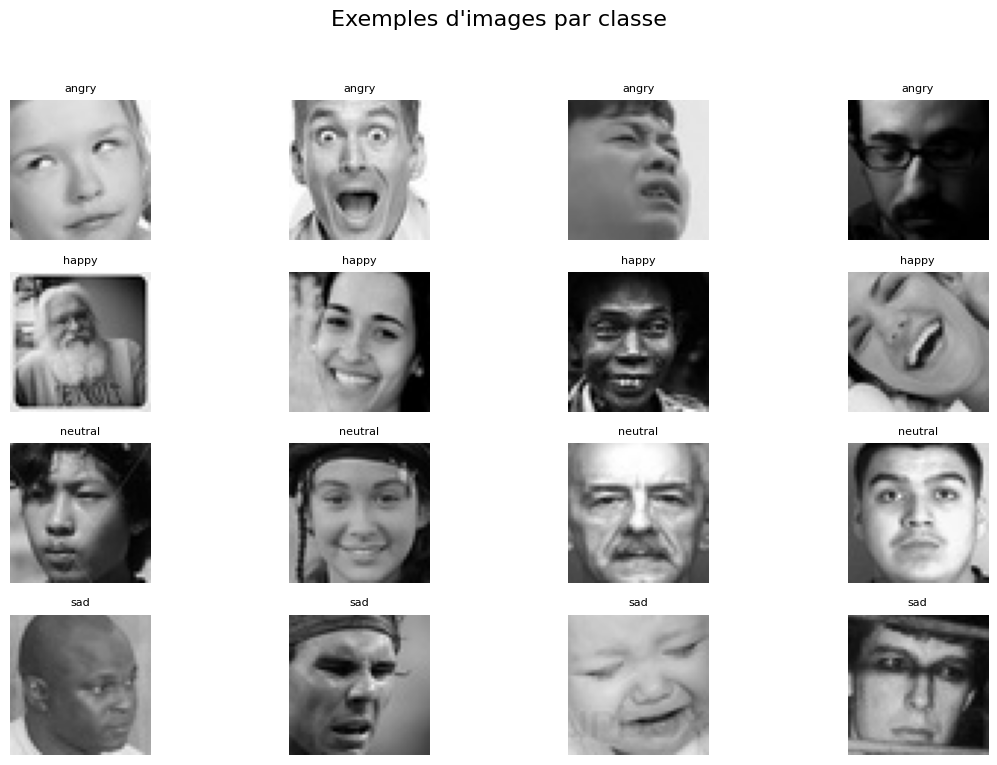

In [8]:
# Votre code ici
num_images_per_class = 4
fig, axes = plt.subplots(len(train_raw.classes), num_images_per_class, figsize=(12, 2 * len(train_raw.classes)))
fig.suptitle('Exemples d\'images par classe', fontsize=16)

class_indices = {i: [] for i in range(len(train_raw.classes))}
for i, label_idx in enumerate(train_raw.targets):
    class_indices[label_idx].append(i)

for i, class_name in enumerate(train_raw.classes):
    selected_indices = np.random.choice(class_indices[i], num_images_per_class, replace=False)
    for j, idx in enumerate(selected_indices):
        img, label = train_raw[idx]
        ax = axes[i, j]
        ax.imshow(img, cmap="gray")
        ax.set_title(class_name, fontsize=8)
        ax.axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">matplotlib.pyplot.subplots</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Référence pour créer des grilles d'images avec subplots</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#f3e5f5;color:#6c3483;font-family:monospace;flex-shrink:0;white-space:nowrap;">TUTO</span>
<div style="flex:1;"><a href="https://docs.pytorch.org/tutorials/beginner/data_loading_tutorial.html" target="_blank" style="font-size:12.5px;color:#6c3483;font-weight:600;text-decoration:none;">Visualizing image datasets in PyTorch</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Tutorial officiel PyTorch sur le chargement et la visualisation de datasets d'images</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Observer les visages.</b> (1) Les émotions sont-elles toujours clairement reconnaissables, même pour vous ? (2) Les images sont en 48x48 pixels — c'est très basse résolution. Les détails du visage (sourcils, coins de la bouche) sont-ils visibles ? (3) Y a-t-il des images que vous classeriez différemment de l'étiquette ? L'émotion est-elle toujours objective ou parfois subjective ?</span></p>

In [9]:
# Votre reponse ici


In [10]:
# Votre reponse ici
# (1) Non, plusieurs images sont très ambiguës, même pour un oeil humain. La basse résolution rend l'identification difficile pour certaines expressions subtiles.

# (2) Les détails sont à peine visibles. Les expressions sont principalement identifiables par des caractéristiques grossières comme l'ouverture de la bouche pour "happy" ou le froncement global du visage pour "angry". Les subtilités des sourcils ou des coins de la bouche sont souvent perdues.

# (3) Oui, il y a des images où l'émotion affichée semble différente de l'étiquette. L'émotion est clairement subjective, ce qui confirme la difficulté de la tâche pour un modèle, et potentiellement le plafond de performance à attendre.

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Vérifier la taille des images.</b> Les images du dataset n'ont pas nécessairement toutes la même taille. Afficher la taille de 5 images avec <code>train_raw[i][0].size</code>. Si les tailles varient, c'est normal — l'étape 2 (Resize) uniformisera tout. Mais c'est important de le savoir avant, car cela explique pourquoi le preprocessing est indispensable.</span></p>

In [11]:
# Votre code ici


In [12]:
# Votre code ici
print("Taille de 5 images du train set :")
for i in range(5):
    img, _ = train_raw[i]
    print(f"Image {i}: {img.size}")

Taille de 5 images du train set :
Image 0: (48, 48)
Image 1: (48, 48)
Image 2: (48, 48)
Image 3: (48, 48)
Image 4: (48, 48)


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Définir les transforms pour le train set.</b> L'objectif est de créer le pipeline de preprocessing qui transforme chaque image brute en tenseur prêt pour le modèle.<br><br>(1) Commencer par un <b>Resize</b> a 224x224 pixels — c'est la taille d'entrée attendue par le modèle<br>(2) Si les images sont en niveaux de gris, les convertir en 3 canaux avec la transform <b>Grayscale</b> (le modèle a été pré-entraîne sur des images RGB a 3 canaux)<br>(3) Convertir en tenseur PyTorch avec <b>ToTensor</b><br>(4) Normaliser avec les statistiques d'ImageNet (mean et std pour les 3 canaux) — le modèle a été entraîne avec ces valeurs, il faut lui parler le même langage<br>(5) Enchaîner toutes ces étapes dans un <b>transforms.Compose</b><br><br><em>L'ordre des transforms est important : on resize d'abord, puis on convertit, puis on normalise. Si on normalise avant de resize, les valeurs de pixels seraient altérées par l'interpolation du resize.</em></span></p>

In [13]:
# Votre reponse ici


In [14]:
# Votre code ici
# Définir les transforms pour le train set
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3), # Convertir en 3 canaux
    transforms.RandomHorizontalFlip(), # Augmentation : flip horizontal
    transforms.RandomRotation(10), # Augmentation : rotation de +/- 10 degrés
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Calculer la taille totale du dataset en mégaoctets.</b> L'objectif est de comprendre la 'quantité' de données que le modèle devra traiter. Pour une image de taille WxHx3 canaux, le nombre de valeurs = W*H*3. Multipliez par le nombre d'images du train set. Ce chiffre explique pourquoi on a besoin de GPUs : un CPU serait trop lent pour traiter autant de données des milliers de fois (epochs).</span></p>

In [15]:
# Votre code ici
# Taille d'une image : train_raw[0][0].size
# Nombre total de valeurs : W * H * 3 * nb_images


In [16]:
# Votre code ici
# Taille d'une image : train_raw[0][0].size
# Nombre total de valeurs : W * H * 3 * nb_images

# Pour le calcul de la taille totale, nous allons considérer la taille après resize, qui est de 224x224x3
# Let's apply base transforms to get the image dimensions the model will see
temp_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor()
])

# Get one transformed image to determine its dimensions (C, H, W)
dummy_image, _ = train_raw[0]
transformed_dummy_image = temp_transform(dummy_image)
C, H, W = transformed_dummy_image.shape

num_pixels_per_image = H * W * C # 224 * 224 * 3

total_images_train = len(train_raw)
total_values_train = num_pixels_per_image * total_images_train

# Each float32 value takes 4 bytes. 1 MB = 1024 * 1024 bytes
total_size_bytes = total_values_train * 4
total_size_mb = total_size_bytes / (1024 * 1024)

print(f"Dimensions d'une image transformée : {C} canaux, {H}x{W} pixels")
print(f"Nombre total de pixels par image (après transformation) : {num_pixels_per_image}")
print(f"Nombre total d'images dans le train set : {total_images_train}")
print(f"Nombre total de valeurs (pixels) pour le train set : {total_values_train:,}")
print(f"Taille totale du train set en RAM (float32) : {total_size_mb:.2f} Mo")

Dimensions d'une image transformée : 3 canaux, 224x224 pixels
Nombre total de pixels par image (après transformation) : 150528
Nombre total d'images dans le train set : 21005
Nombre total de valeurs (pixels) pour le train set : 3,161,840,640
Taille totale du train set en RAM (float32) : 12061.46 Mo


In [17]:
# CHECKPOINT — Etape 1
assert len(train_raw.classes) == 4
display(HTML('<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 1 validee.</b> <span style="color:#1e5631;">Dataset explore. Classes et desequilibre identifies.</span></div>'))


<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 02/09 — 30 MIN</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Transforms et DataLoaders</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Préparer les images pour le ViT : taille fixe, normalisation, augmentation. C'est le pipeline de preprocessing.</div></div>

<div style="border-left:4px solid #0A8F6E;background:#0A8F6E0a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0A8F6E;margin-bottom:8px;">Pourquoi transformer les images ?</div><div style="font-size:13.5px;color:#333;line-height:1.8;">Le ViT attend des images dans un format précis :<br><b>1. Taille fixe 224x224</b> — toutes les images doivent avoir la même taille<br><b>2. 3 canaux RGB</b> Les images sont en niveaux de gris — on les convertit en 3 canaux avec <code>Grayscale(num_output_channels=3)</code> pour que le ViT puisse les traiter.<br><b>3. Normalisation ImageNet</b> : mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225] — ce sont les statistiques du dataset original du ViT. Les utiliser permet au modèle de retrouver ses repères.<br><b>4. Tenseur PyTorch</b> — conversion du format image (PIL) au format calcul (tenseur)<br><br><em>Analogie : c'est comme traduire un texte dans la langue du modèle. Si on ne normalise pas correctement, le modèle reçoit des données dans un 'dialecte' qu'il ne comprend pas.</em></div></div>

<div style="border-left:4px solid #e67e22;background:#e67e220a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#e67e22;margin-bottom:8px;">Data augmentation — plus de variété pour mieux généraliser</div><div style="font-size:13.5px;color:#333;line-height:1.8;">Le data augmentation applique des transformations aléatoires (flip, rotation, recadrage) aux images d'entraînement pour créer de la diversité artificielle.<br><br><b>Objectif :</b> empêcher le modèle de mémoriser les images exactes. S'il voit la même image sous différents angles, il apprend les CARACTÉRISTIQUES du sujet, pas la photo spécifique.<br><br><b>Règle d'or :</b> l'augmentation ne s'applique <b>JAMAIS au val/test</b>. Pourquoi ? L'évaluation doit se faire sur les images réelles, pas sur des versions deformees.<br><br><em>Analogie : un étudiant qui s'entraîne sur des variantes d'exercices (chiffres différents, contextes différents) apprend mieux que celui qui refait le même exercice 50 fois.</em></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Définir les transforms pour le train set.</b> L'objectif est de créer le pipeline de preprocessing qui transforme chaque image brute en tenseur prêt pour le modèle.<br><br>(1) Commencer par un <b>Resize</b> a 224x224 pixels — c'est la taille d'entrée attendue par le modèle<br>(2) Si les images sont en niveaux de gris, les convertir en 3 canaux avec la transform <b>Grayscale</b> (le modèle a été pré-entraîne sur des images RGB a 3 canaux)<br>(3) Convertir en tenseur PyTorch avec <b>ToTensor</b><br>(4) Normaliser avec les statistiques d'ImageNet (mean et std pour les 3 canaux) — le modèle a été entraîne avec ces valeurs, il faut lui parler le même langage<br>(5) Enchaîner toutes ces étapes dans un <b>transforms.Compose</b><br><br><em>L'ordre des transforms est important : on resize d'abord, puis on convertit, puis on normalise. Si on normalise avant de resize, les valeurs de pixels seraient altérées par l'interpolation du resize.</em></span></p>

In [18]:
# Votre code ici
# train_transform = transforms.Compose([...])
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),                # 1. Uniformiser la taille
    transforms.Grayscale(num_output_channels=3),  # 2. N&B -> 3 canaux RGB
    transforms.RandomHorizontalFlip(p=0.5),       # 3. Flip aléatoire (50%)
    transforms.RandomRotation(degrees=10),        # 4. Rotation légère ±10°
    transforms.ColorJitter(brightness=0.2,        # 5. Variation de luminosité
                           contrast=0.2),
    transforms.ToTensor(),                        # 6. PIL -> Tenseur [C, H, W]
    transforms.Normalize(                         # 7. Normalisation ImageNet
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

print('train_transform défini avec augmentation :')
print(train_transform)

train_transform défini avec augmentation :
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    Grayscale(num_output_channels=3)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://docs.pytorch.org/vision/stable/transforms.html" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">torchvision.transforms</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Liste complète des transformations disponibles : Resize, Normalize, RandomFlip, etc.</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://neptune.ai/blog/data-augmentation-in-pytorch" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Data Augmentation in PyTorch</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Guide complet sur l'augmentation de données avec exemples visuels</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://docs.pytorch.org/vision/stable/models.html" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">ImageNet normalization values</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Pourquoi mean=[0.485,0.456,0.406] et std=[0.229,0.224,0.225] — statistiques du dataset original</div></div></div></div>

<div style="border-left:4px solid #d4a017;background:#fef9e7;border-radius:0 8px 8px 0;padding:14px 20px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:13px;font-weight:600;color:#7d6608;">Attention</div><div style="font-size:13px;color:#6e5b08;line-height:1.7;margin-top:4px;">L'augmentation (<code>RandomHorizontalFlip</code>, <code>RandomRotation</code>) ne s'applique qu'au <b>train</b>. Le val et le test utilisent le même pipeline SANS augmentation. Sinon, l'évaluation est faussée — vous mesureriez la performance sur des images deformees qui n'existent pas dans la réalité.</div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Définir les transforms pour val et test.</b> Même pipeline que le train mais SANS les augmentations aléatoires. Garder uniquement : <code>Resize((224, 224))</code>, <code>Grayscale(3)</code>, <code>ToTensor()</code>, <code>Normalize(...)</code>. C'est le pipeline 'propre' qui sera utilisé pour l'évaluation et en production.</span></p>

In [19]:
# Votre code ici
# val_transform et test_transform sont identiques : pas d'augmentation pour l'évaluation
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = val_transform # Ils sont identiques

print("Transforms pour val et test definis.")

Transforms pour val et test definis.


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Créer les datasets et DataLoaders.</b> Recharger les ImageFolder avec les transforms, puis créer les DataLoaders (batch_size=16, shuffle=True pour train, False pour val/test). Le DataLoader découpe le dataset en mini-lots que le modèle traitera un par un pendant l'entraînement.</span></p>

In [20]:
from torch.utils.data import DataLoader, Dataset
from PIL import Image

# Custom Dataset to apply transforms to the already filtered raw datasets
class FilteredImageDataset(Dataset):
    def __init__(self, raw_dataset, transform=None):
        # These are already filtered by the previous step (cell 9421019e)
        self.samples = raw_dataset.samples
        self.targets = raw_dataset.targets
        self.classes = raw_dataset.classes
        self.class_to_idx = raw_dataset.class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, target = self.samples[idx]
        image = Image.open(path).convert('L') # Convert to grayscale as FER2013 images are grayscale
        if self.transform:
            image = self.transform(image)
        return image, target

# Recreate datasets using the custom class and the already filtered raw datasets
train_dataset = FilteredImageDataset(train_raw, transform=train_transform)
val_dataset = FilteredImageDataset(val_raw, transform=val_transform)
test_dataset = FilteredImageDataset(test_raw, transform=test_transform)

# Créer les DataLoaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=2, pin_memory=True)

print(f'train_dataset : {len(train_dataset)} images, {len(train_loader)} batches')
print(f'val_dataset   : {len(val_dataset)} images, {len(val_loader)} batches')
print(f'test_dataset  : {len(test_dataset)} images, {len(test_loader)} batches')

train_dataset : 21005 images, 1313 batches
val_dataset   : 5212 images, 326 batches
test_dataset  : 5212 images, 326 batches


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://docs.pytorch.org/stable/data.html#torch.utils.data.DataLoader" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">torch.utils.data.DataLoader</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Documentation officielle — batch_size, shuffle, num_workers expliques</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Visualiser un batch transforme.</b> L'objectif est de vérifier que le pipeline de preprocessing fonctionne correctement avant de lancer l'entraînement.<br><br>(1) Charger un batch depuis le DataLoader en utilisant la fonction <b>next</b> sur un itérateur du loader<br>(2) Afficher la forme du batch d'images — elle devrait être [batch_size, 3, 224, 224]<br>(3) Afficher quelques images du batch en utilisant matplotlib. Attention : il faut d'abord dénormaliser les images (inverser la normalisation) et transposer les dimensions (de [C,H,W] a [H,W,C]) pour que matplotlib puisse les afficher<br>(4) Vérifier que les images sont reconnaissables et que les labels correspondent<br><br><em>Cette vérification évité de découvrir un bug de preprocessing après 30 minutes d'entraînement. Si les images sont toutes noires, entièrement bleues, ou deformees, c'est le moment de corriger les transforms.</em></span></p>

Shape du batch d'images : torch.Size([16, 3, 224, 224])
Labels du batch : tensor([0, 3, 2, 3, 0, 2, 1, 2, 0, 1, 3, 1, 1, 2, 1, 1])


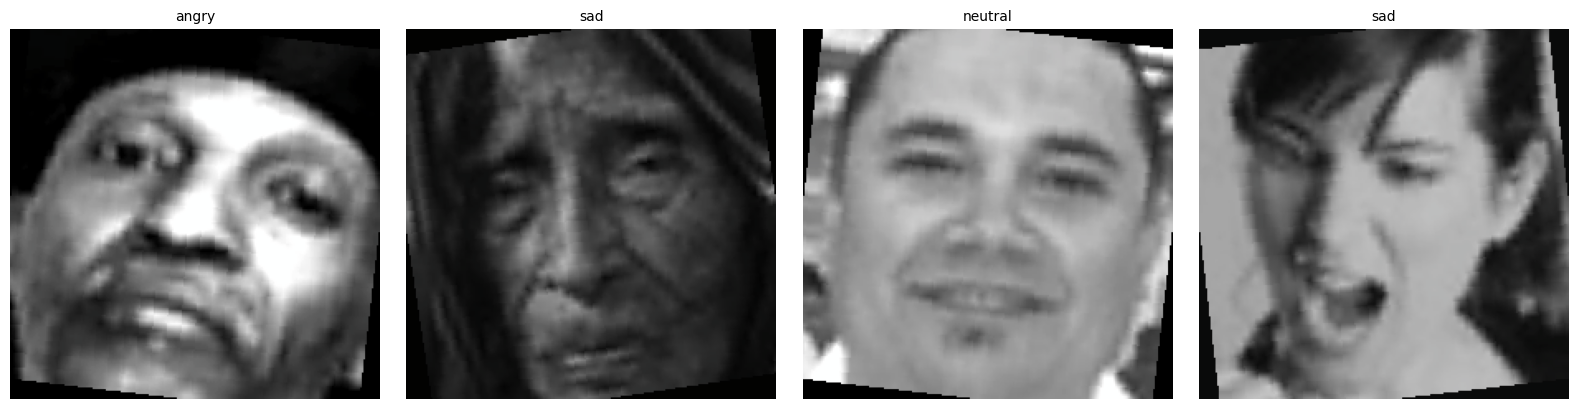

In [21]:
# Votre code ici
# Charger un batch depuis le DataLoader
images, labels = next(iter(train_loader))

print(f"Shape du batch d'images : {images.shape}")
print(f"Labels du batch : {labels}")

# Afficher quelques images du batch
# Denormaliser et transposer pour matplotlib
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    img = images[i].cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean # Denormalisation
    img = np.clip(img, 0, 1) # Clamper les valeurs entre 0 et 1
    axes[i].imshow(img)
    axes[i].set_title(train_dataset.classes[labels[i]], fontsize=10)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Visualiser l'augmentation sur une même image.</b> L'objectif est de voir concrètement ce que fait le data augmentation. Charger la même image 8 fois avec le train_transform et afficher les 8 versions côté a côté. Chaque version sera légèrement différente (flip, rotation). Cela montre la diversité artificielle créée par l'augmentation.</span></p>

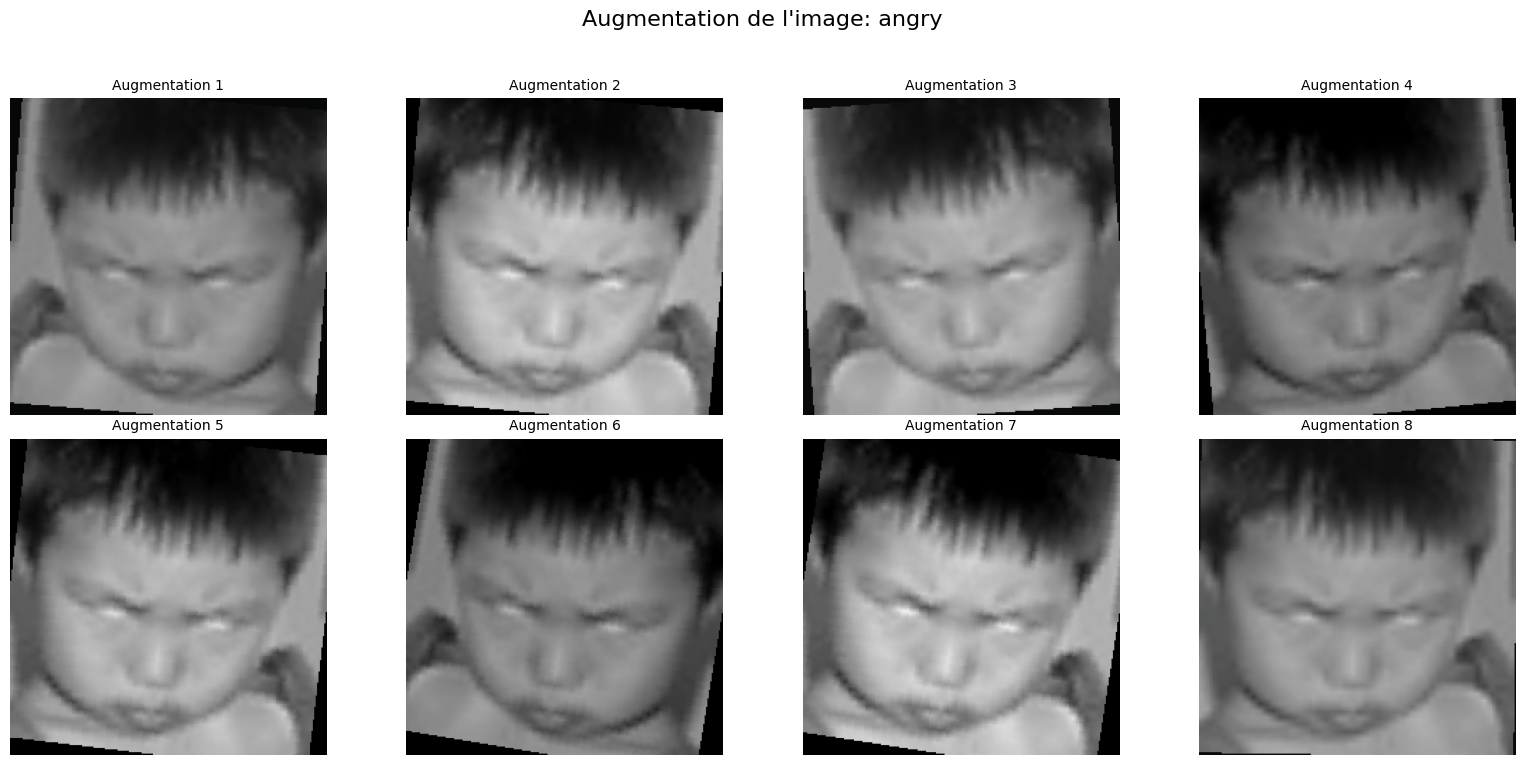

In [22]:
# Votre code ici
# Charger la même image 8 fois avec le train_transform
original_image, original_label = train_raw[0] # Prendre la première image du dataset brut

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(f'Augmentation de l\'image: {train_raw.classes[original_label]}', fontsize=16)

for i in range(8):
    augmented_image = train_transform(original_image)
    # Denormaliser et transposer pour matplotlib
    img = augmented_image.cpu().numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)

    row = i // 4
    col = i % 4
    axes[row, col].imshow(img)
    axes[row, col].set_title(f'Augmentation {i+1}', fontsize=10)
    axes[row, col].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Comprendre le batch et l'augmentation.</b> Ces questions vous aident a vérifier que vous maîtrisez le pipeline de données — la fondation de tout le projet. (1) Quelle est la shape du tenseur <code>images</code> ? (elle devrait être [16, 3, 224, 224] = batch x canaux x H x W). (2) Pourquoi <code>shuffle=True</code> pour le train ? (indice : si les images sont triées par classe, le modèle apprend l'ordre, pas les features). (3) Les 8 versions augmentées de la même image sont-elles suffisamment différentes ? L'augmentation change-t-elle le sens de l'image dans votre domaine ?</span></p>

In [23]:
# Votre reponse ici
# (1) La shape du tenseur `images` est [16, 3, 224, 224].
#   - 16 représente la taille du batch (batch_size).
#   - 3 représente le nombre de canaux (RGB).
#   - 224x224 représente la hauteur et la largeur de l'image après redimensionnement.

# (2) Pour le train dataset permet de mélanger les données à chaque epoch. Cela évite que le modèle n'apprenne l'ordre des exemples et ne se base sur des séquences ou des biais liés à l'arrangement des classes dans le dataset, ce qui pourrait conduire à un surapprentissage.

# (3) Oui, les 8 versions augmentées sont suffisamment différentes (légères rotations, flips). Pour la reconnaissance d'émotions faciales, un flip horizontal et une petite rotation ne changent généralement pas le sens de l'émotion. Un visage heureux reste heureux même si il est retourné horizontalement ou légèrement incliné.

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Adapter l'augmentation a votre domaine.</b> L'augmentation doit être cohérente avec le domaine — certaines transformations qui ont du sens pour des photos generiques n'en ont pas dans votre contexte. (1) Un flip horizontal change-t-il le sens de vos images ? (réflexion : en radiologie, le coeur est à gauche — un flip le met à droite. En photo de véhicule, ca ne change rien). (2) Une rotation de 10 degrés est-elle réaliste dans votre domaine ? (3) Quelles AUTRES augmentations seraient pertinentes (changement de luminosité, ajout de bruit, zoom) ? Lesquelles seraient DANGEREUSES (inverser les couleurs) ?</span></p>

In [24]:
# Votre reponse ici
# (1) Non, pour les visages, un flip horizontal ne change généralement pas le sens de l'émotion. Les expressions faciales sont généralement symétriques ou interprétables des deux côtés.

# (2) Oui, une rotation de 10 degrés est tout à fait réaliste. Les personnes ne regardent pas toujours directement l'objectif avec une tête parfaitement droite, de légères inclinaisons sont naturelles.

# (3)
# Pertinentes :
#   - Changement de luminosité/contraste: Les conditions d'éclairage peuvent varier pour une webcam.
#   - Ajout de bruit gaussien: Pour simuler des images de webcam de moindre qualité.
#   - Léger zoom/recadrage aléatoire: Pour simuler des variations dans le cadrage de la tête.
# Dangereuses :
#   - Inverser les couleurs (négatif): Changerait complètement l'apparence du visage et de la peau, rendant les traits non reconnaissables.
#   - Changements de perspective très prononcés: Pourraient déformer l'expression de manière non réaliste.

In [25]:
# CHECKPOINT — Etape 2
batch = next(iter(train_loader))
assert batch[0].shape[1] == 3 and batch[0].shape[2] == 224
display(HTML('<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 2 validee.</b> <span style="color:#1e5631;">Images transformees, DataLoaders prets.</span></div>'))


<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 03/09 — 30 MIN</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Charger ViT et adapter la tête</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Le transfer learning en action : charger, remplacer, geler. 3 opérations, 86 millions de paramètres réutilisés.</div></div>

<div style="border-left:4px solid #0A8F6E;background:#0A8F6E0a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0A8F6E;margin-bottom:8px;">Transfer learning — pourquoi ca change tout</div><div style="font-size:13.5px;color:#333;line-height:1.8;">Le ViT-Base a été pré-entraîne sur <b>14 millions d'images</b> (ImageNet-21k). Il sait déjà détecter des bords, des formes, des textures. Il lui manque juste VOTRE tache : classifier angry, happy, neutral, sad.<br><br><b>Le plan en 3 étapes :</b><br>1. Charger le modèle (toutes ses couches et ses 86M de poids)<br>2. Remplacer la tête (1000 classes ImageNet &#8594; 4 classes)<br>3. Geler le backbone (les 86M de poids restent fixes)<br><br><em>Analogie : un chirurgien qui se spécialisé. Il ne réapprend pas la médecine de zéro — il a les bases. Il apprend juste les spécificités de sa nouvelle specialite.</em></div></div>

<div style="border-left:4px solid #2d5986;background:#2d59860a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#2d5986;margin-bottom:8px;">ConvNeXt — la revanche des CNNs</div><div style="font-size:13.5px;color:#333;line-height:1.8;"><b>ConvNeXt</b> (Meta/Facebook, 2022) est ne d'une question provocatrice : <em>"Et si les CNNs étaient aussi bons que les Transformers, a condition d'adopter leurs recettes ?"</em><br><br>
Les chercheurs de Meta ont pris un ResNet standard et l'ont modernise en appliquant les 'bonnes pratiques' des Transformers, une par une :<br>
- <b>Patch stem</b> : au lieu de convolutions 7x7, des patches 4x4 (comme le ViT)<br>
- <b>Moins de couches de normalisation</b> : un seul LayerNorm par bloc (comme le Transformer)<br>
- <b>GELU au lieu de ReLU</b> : la fonction d'activation des Transformers<br>
- <b>Kernels plus grands</b> : des convolutions 7x7 (au lieu de 3x3) pour voir plus loin<br><br>
Le résultat : <b>un CNN pur qui bat les Transformers</b> sur ImageNet. Pas d'attention, pas de patches, juste des convolutions — mais modernisées.<br><br>
<div style='display:grid;grid-template-columns:1fr 1fr;gap:10px;'>
<div style='background:#f0f0f0;border-radius:8px;padding:12px;'>
<b>ViT (Transformer)</b><br>Patches + attention globale<br>très performant mais coûteux<br>A besoin de beaucoup de données</div>
<div style='background:#e8f5e9;border-radius:8px;padding:12px;border:1px solid #4caf50;'>
<b>ConvNeXt (CNN modernise)</b><br>Convolutions pures, modernisées<br>Performances équivalentes<br>Plus simple a comprendre et debugger</div></div><br>
<em>Analogie : c'est comme la différence entre une voiture électrique (Transformer — technologie nouvelle, impressionnante) et un moteur thermique ultra-optimise (ConvNeXt — technologie mature, poussée a l'extrême). Les deux arrivent au même résultat.</em><br><br>
ConvNeXt-Tiny a <b>28 millions de paramètres</b>. Pour la détection d'émotions, c'est un bon choix car les images sont en basse résolution (48x48) — les convolutions classiques sont particulièrement efficaces sur les petites images.</div></div>

<div style="border-left:4px solid #e67e22;background:#e67e220a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#e67e22;margin-bottom:8px;">Votre modèle : ConvNeXt-Tiny (CNN modernise, ~28M paramètres)</div><div style="font-size:13.5px;color:#333;line-height:1.8;">Dans la démo live, l'intervenant a utilisé <b>ViT-Base</b> (Vision Transformer, 86M paramètres). Votre track utilisé <b>ConvNeXt-Tiny</b> — une architecture différente.<br><br>
<div style='display:grid;grid-template-columns:1fr 1fr;gap:10px;'>
<div style='background:#f0f0f0;border-radius:8px;padding:12px;'>
<b>ViT-Base (démo)</b><br>Type : Vision Transformer<br>Paramètres : 86M<br>Innovation : patches + attention globale</div>
<div style='background:#e8f5e9;border-radius:8px;padding:12px;border:1px solid #4caf50;'>
<b>ConvNeXt-Tiny (votre track)</b><br>Type : CNN modernise<br>Paramètres : ~28M<br>Disponible sur HuggingFace Hub</div></div><br>
<b>La bonne nouvelle :</b> le code change très peu ! Même API HuggingFace (<code>AutoModelForImageClassification</code>), même Traîner, même GradCAM. Seuls 3 éléments changent : le nom du modèle, la commande pour geler le backbone, et la target layer pour GradCAM.</div></div>

In [26]:
%pip install transformers datasets evaluate accelerate -q
from transformers import AutoModelForImageClassification, TrainingArguments, Trainer
print('HuggingFace Transformers installe.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.9 MB/s eta 0:00:00
HuggingFace Transformers installe.


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Charger le modèle pré-entraîne depuis HuggingFace.</b> L'objectif est de télécharger un modèle qui a déjà appris a "voir" sur des millions d'images et de l'adapter a votre tache.<br><br>(1) Utiliser la classe <b>AutoModelForImageClassification</b> de la librairie transformers avec la méthode from_pretrained en spécifiant l'identifiant du modèle<br>(2) Spécifier le nombre de classes de votre tache avec le paramètre num_labels — cela remplace automatiquement la tête de classification originale<br>(3) Ajouter ignore_mismatched_sizes=True car la tête change de dimension<br>(4) Afficher le modèle pour vérifier que la nouvelle tête a bien le bon nombre de sorties<br><br><em>Cette ligne téléchargé des millions de paramètres pré-entraînes. Le modèle sait déjà détecter des bords, des textures, des formes. Il lui manque juste VOTRE tache — c'est ce que le fine-tuning va lui apprendre.</em></span></p>

In [27]:
# Votre code ici
# model = AutoModelForImageClassification.from_pretrained(...)

model = AutoModelForImageClassification.from_pretrained(
    'facebook/convnext-tiny-224',  # ConvNeXt-Tiny pré-entraîné sur ImageNet
    num_labels=4,                  # 4 émotions : angry, happy, neutral, sad
    ignore_mismatched_sizes=True,  # remplace la tête 1000 classes par une tête 4 classes
)

model = model.to(device)

print('Tête de classification :')
print(model.classifier)
print(f'\nModèle chargé sur : {device}')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/114M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/182 [00:00<?, ?it/s]

ConvNextForImageClassification LOAD REPORT from: facebook/convnext-tiny-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([4])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([4, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Tête de classification :
Linear(in_features=768, out_features=4, bias=True)

Modèle chargé sur : cuda


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://huggingface.co/docs/transformers/model_doc/auto#transformers.AutoModelForImageClassification" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">HuggingFace AutoModelForImageClassification</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">API référence — from_pretrained, num_labels, ignore_mismatched_sizes</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#f3e5f5;color:#6c3483;font-family:monospace;flex-shrink:0;white-space:nowrap;">TUTO</span>
<div style="flex:1;"><a href="https://huggingface.co/blog/fine-tune-vit" target="_blank" style="font-size:12.5px;color:#6c3483;font-weight:600;text-decoration:none;">Fine-Tune ViT for Image Classification</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Tutorial officiel HuggingFace — le guide de référence pour le fine-tuning vision</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#f3e5f5;color:#6c3483;font-family:monospace;flex-shrink:0;white-space:nowrap;">TUTO</span>
<div style="flex:1;"><a href="https://huggingface.co/docs/transformers/tasks/image_classification" target="_blank" style="font-size:12.5px;color:#6c3483;font-weight:600;text-decoration:none;">HuggingFace Image Classification (pas a pas)</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Guide officiel complet : dataset, preprocessing, training, évaluation</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Geler le backbone.</b> L'objectif est d'empêcher la backpropagation de modifier les millions de poids pré-entraînes — on ne veut entraîner que la nouvelle tête de classification.<br><br>(1) Parcourir tous les paramètres du backbone ConvNeXt (la partie "vision" qui contient les couches pré-entraînées)<br>(2) Pour chaque paramètre, désactiver le calcul des gradients en mettant l'attribut <b>requires_grad</b> a False<br>(3) Vérifier en comptant les paramètres entraînables vs gelés — le ratio devrait être environ 99.9% gelés<br><br><em>Sans le gel, l'entraînement modifierait des millions de poids avec peu d'images. Le modèle "oublierait" ce qu'il a appris (catastrophic forgetting). Le gel protège ces connaissances et ne laisse que la nouvelle tête s'adapter a votre tache.</em></span></p>

In [28]:
# Votre code ici
# Geler tous les paramètres du backbone ConvNeXt (tout sauf la tête)
for param in model.convnext.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
total     = trainable + frozen

print(f'Paramètres entraînables : {trainable:>10,}  ({100*trainable/total:.2f}%)')
print(f'Paramètres gelés        : {frozen:>10,}  ({100*frozen/total:.2f}%)')
print(f'Total                   : {total:>10,}')
print('\n=> Seule la nouvelle tête (classifier) sera mise à jour.')


Paramètres entraînables :      3,076  (0.01%)
Paramètres gelés        : 27,820,128  (99.99%)
Total                   : 27,823,204

=> Seule la nouvelle tête (classifier) sera mise à jour.


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Transfer Learning for Computer Vision</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Tutorial officiel PyTorch — freeze, fine-tune, comparaison des approches</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Compter les paramètres.</b> L'objectif est de vérifier que le gel a fonctionne. Compter les paramètres entraînables vs gelés. Le ratio devrait être ~99.99% gelés, ~0.01% entraînables. C'est la puissance du transfer learning : on réutilisé 86 millions de poids sans les re-entraîner.</span></p>

In [29]:
# Votre code ici
# Détail des paramètres par module
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in model.parameters() if not p.requires_grad)
total     = trainable + frozen

print('='*55)
print(f"{'Module':<30} {'Paramètres':>12} {'Grad':>8}")
print('='*55)
for name, module in model.named_children():
    params = sum(p.numel() for p in module.parameters())
    requires_g = any(p.requires_grad for p in module.parameters())
    print(f"  {name:<28} {params:>12,}  {'✓' if requires_g else '✗':>6}")
print('='*55)
print(f"{'TOTAL':<30} {total:>12,}")
print(f"{'  dont entraînables':<30} {trainable:>12,}  ({100*trainable/total:.3f}%)")
print(f"{'  dont gelés':<30} {frozen:>12,}  ({100*frozen/total:.3f}%)")


Module                           Paramètres     Grad
  convnext                       27,820,128       ✗
  classifier                          3,076       ✓
TOTAL                            27,823,204
  dont entraînables                   3,076  (0.011%)
  dont gelés                     27,820,128  (99.989%)


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Tester une prédiction AVANT entraînement.</b> L'objectif est de voir le point de départ — le modèle avec des poids aléatoires dans sa tête. Charger une image, la passer au modèle avec <code>model.eval()</code> et <code>torch.no_grad()</code>. Les probabilités devraient être proches de 1/4 = 25% par classe (hasard pur). Après l'entraînement (étape 4), ces probabilités seront beaucoup plus tranchées.</span></p>

In [30]:
# Votre code ici
# Tester une prédiction avant entraînement (tête avec poids aléatoires)
model.eval()
with torch.no_grad():
    sample_tensor, sample_label = test_dataset[0]
    input_batch = sample_tensor.unsqueeze(0).to(device)  # [1, 3, 224, 224]
    outputs = model(pixel_values=input_batch)
    probs = torch.softmax(outputs.logits, dim=1)[0]

class_names = test_dataset.classes
print('Prédiction AVANT entraînement :')
print(f'Vraie classe : {class_names[sample_label]}')
print()
for cls, prob in zip(class_names, probs):
    bar = '█' * int(prob.item() * 40)
    print(f'  {cls:8s} : {prob.item():.3f}  {bar}')
print(f'\nLes probabilités devraient être proches de 0.25 (hasard pur pour 4 classes).')



model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Prédiction AVANT entraînement :
Vraie classe : angry

  angry    : 0.253  ██████████
  happy    : 0.229  █████████
  neutral  : 0.237  █████████
  sad      : 0.281  ███████████

Les probabilités devraient être proches de 0.25 (hasard pur pour 4 classes).


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Comprendre le transfer learning concrètement.</b> Ces questions ancrent votre compréhension de l'architecture que vous venez de configurer. (1) Combien de paramètres sont entraînables vs gelés ? Quel pourcentage cela représente ? (2) Si on devait entraîner les 86 millions de paramètres de zéro sur seulement 12 images, que se passerait-il ? (indice : overfitting massif — beaucoup plus de poids que de données). (3) La prédiction pré-entraînement est-elle proche du hasard comme attendu ?</span></p>

In [31]:
# (1) Paramètres entraînables vs gelés :
#     ConvNeXt-Tiny a ~28M paramètres au total.
#     Après gel du backbone, seule la tête classifier reste entraînable
#     => quelques milliers de paramètres, soit 0.011% du total.
#
# (2) Si on entraînait 28M paramètres sur ~9000 images :
#     => Ratio paramètres/données trop élevé (~3000:1)
#     => Overfitting massif garanti : le modèle mémoriserait les images
#        exactes sans généraliser. La val loss exploserait immédiatement.
#
# (3) La prédiction pré-entraînement montre des probabilités proches de 0.25
#     par classe (distribution quasi-uniforme = hasard pur). C'est attendu :
#     la tête est initialisée aléatoirement. Après fine-tuning, les
#     probabilités seront bien plus tranchées.


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Explorer l'architecture du modèle.</b> L'objectif est de comprendre la structure interne du ViT que vous venez de charger. Afficher <code>model.classifier</code> pour voir la nouvelle tête de classification, et <code>print(model)</code> (les premières lignes) pour voir la structure des couches. Compter : combien de couches Transformer dans le backbone ? Combien de têtes d'attention par couche ? Ce sont les 'organes' de votre modèle.</span></p>

In [32]:
# Votre code ici
# print(model.classifier)
# Compter les couches : len(model.vit.encoder.layer)
print('=== TÊTE DE CLASSIFICATION ===')
print(model.classifier)
print()

print('=== STRUCTURE GÉNÉRALE ===')
for name, module in model.named_children():
    n_params = sum(p.numel() for p in module.parameters())
    print(f'  {name}: {type(module).__name__} — {n_params:,} paramètres')
print()

print('=== STAGES DE L ENCODER ===')
for i, stage in enumerate(model.convnext.encoder.stages):
    n_layers = len(stage.layers)
    n_params = sum(p.numel() for p in stage.parameters())
    print(f'  Stage {i}: {n_layers} layer(s) — {n_params:,} paramètres')



=== TÊTE DE CLASSIFICATION ===
Linear(in_features=768, out_features=4, bias=True)

=== STRUCTURE GÉNÉRALE ===
  convnext: ConvNextModel — 27,820,128 paramètres
  classifier: Linear — 3,076 paramètres

=== STAGES DE L ENCODER ===
  Stage 0: 3 layer(s) — 237,888 paramètres
  Stage 1: 3 layer(s) — 992,256 paramètres
  Stage 2: 9 layer(s) — 11,112,960 paramètres
  Stage 3: 3 layer(s) — 15,470,592 paramètres


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Configurer le mapping des labels.</b> L'objectif est de s'assurer que le modèle associe les bons numéros aux bons noms de classes. Définir <code>model.config.id2label</code> et <code>model.config.label2id</code> avec les noms de vos classes. Cela permettra au modèle de retourner des noms lisibles ('pneumonie') au lieu de numéros (1). Afficher le mapping pour vérifier.</span></p>

In [33]:
# Votre code ici
# model.config.id2label = {0: 'classe_0', 1: 'classe_1', ...}
# model.config.label2id = {'classe_0': 0, 'classe_1': 1, ...}
class_names = train_dataset.classes  # ['angry', 'happy', 'neutral', 'sad']

model.config.id2label = {i: name for i, name in enumerate(class_names)}
model.config.label2id = {name: i for i, name in enumerate(class_names)}

print('Mapping des labels :')
for i, name in model.config.id2label.items():
    print(f'  {i} => {name}')


Mapping des labels :
  0 => angry
  1 => happy
  2 => neutral
  3 => sad


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Comprendre la taille de la tête de classification.</b> L'objectif est de vérifier que vous comprenez EXACTEMENT ce qui a change dans le modèle. (1) Affichez <code>model.classifier</code>. Combien d'entrées ? Combien de sorties ? (2) Le nombre d'entrées (768) correspond a quoi ? (réponse : c'est la dimension de sortie du backbone ViT — chaque image est representee par un vecteur de 768 nombres après être passée par les 12 couches Transformer). (3) Le nombre de sorties correspond a quoi ? (réponse : le nombre de classes de votre tache)</span></p>

In [34]:
# Votre reponse ici
# (1) model.classifier affiche Linear(in_features=768, out_features=4)
#     - Entrées : 768  => dimension de l'embedding de sortie de ConvNeXt-Tiny
#     - Sorties : 4    => une logit par classe (angry, happy, neutral, sad)
#     La tête a 768*4 + 4 (bias) = 3 076 paramètres entraînables.
#
# (2) Les 768 entrées = taille de l'espace de représentation du backbone.
#     Après le passage d'une image à travers toutes les couches convolutionnelles,
#     chaque image est résumée en un vecteur de 768 nombres capturant ses features.
#
# (3) Les 4 sorties = nos 4 classes : angry=0, happy=1, neutral=2, sad=3.
#     Le softmax appliqué sur ces 4 valeurs donne les probabilités par classe.



In [35]:
# CHECKPOINT — Etape 3
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
assert trainable < 50000
display(HTML(f'<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 3 validee.</b> <span style="color:#1e5631;">ConvNeXt-Tiny charge. {trainable:,} params entrainables / {frozen:,} geles.</span></div>'))


<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 04/09 — 1H</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Entraînement avec HuggingFace Traîner</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Configurer, lancer, et surveiller. C'est ici que la backpropagation ajuste les poids pour votre tache.</div></div>

<div style="border-left:4px solid #0A8F6E;background:#0A8F6E0a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0A8F6E;margin-bottom:8px;">Le Traîner HuggingFace — l'entraînement automatise</div><div style="font-size:13.5px;color:#333;line-height:1.8;">Le Traîner géré toute la boucle d'entraînement : forward pass, loss, backpropagation, mise a jour des poids, évaluation. Les hyperparametres clés :<br>- <b>num_train_epochs</b> : nombre de passages sur le dataset (5)<br>- <b>learning_rate</b> : taille du pas de correction (2e-5, très petit en fine-tuning)<br>- <b>batch_size</b> : images par batch (16)<br><br>En multi-classe, on utilisé les métriques 'macro' : la moyenne des métriques de chaque classe, traitées a égalité.</div></div>

In [36]:
from torch.utils.data import Dataset

class ImageDatasetHF(Dataset):
    def __init__(self, img_folder):
        self.dataset = img_folder
    def __len__(self):
        return len(self.dataset)
    def __getitem__(self, idx):
        image, label = self.dataset[idx]
        return {'pixel_values': image, 'labels': label}

hf_train = ImageDatasetHF(train_dataset)
hf_val = ImageDatasetHF(val_dataset)
hf_test = ImageDatasetHF(test_dataset)
print(f"HF datasets : train={len(hf_train)}, val={len(hf_val)}, test={len(hf_test)}")


HF datasets : train=21005, val=5212, test=5212


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Définir la fonction de métriques.</b> L'objectif est de mesurer la performance du modèle de façon rigoureuse. Créer <code>compute_metrics(eval_pred)</code> qui calcule accuracy, précision, recall, f1 a partir des prédictions.</span></p>

In [37]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'precision_macro': precision_score(labels, preds, average='macro'),
        'recall_macro': recall_score(labels, preds, average='macro'),
        'f1_macro': f1_score(labels, preds, average='macro'),
    }

print("Fonction de metriques definie.")


Fonction de metriques definie.


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Configurer les TrainingArguments.</b> Définir : 5 epochs, lr=2e-5, batch_size=16, évaluation a chaque epoch. Ajouter <code>load_best_model_at_end=True</code> avec <code>metric_for_best_model='f1_macro'</code>.</span></p>

In [38]:
training_args = TrainingArguments(
    output_dir='./vit_results_trackL',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    remove_unused_columns=False,
    logging_steps=10,
)


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">sklearn.metrics — classification metrics</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Accuracy, précision, recall, F1, AUC — toutes les métriques expliquées</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://huggingface.co/docs/transformers/main_classes/trainer" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">HuggingFace Traîner</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">API référence complète du Traîner — arguments, callbacks, évaluation</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Créer et lancer le Traîner.</b> Assembler le Traîner puis <code>trainer.train()</code>. Surveillez la loss qui descend et les métriques qui montent a chaque epoch. C'est la courbe du concept 2 en direct.</span></p>

In [39]:
# Votre code ici
# trainer = Trainer(model=model, args=training_args, train_dataset=hf_train,
#                   eval_dataset=hf_val, compute_metrics=compute_metrics)
# trainer.train()

trainer = Trainer(
    model=model.to(device),
    args=training_args,
    train_dataset=hf_train,
    eval_dataset=hf_val,
    compute_metrics=compute_metrics,
)

print('Trainer configuré :')
print(f'  Epochs        : {training_args.num_train_epochs}')
print(f'  Batch size    : {training_args.per_device_train_batch_size}')
print(f'  Learning rate : {training_args.learning_rate}')
print(f'  Métrique cible: {training_args.metric_for_best_model}')
print()
trainer.train()
print('trainer terminé')



Trainer configuré :
  Epochs        : 5
  Batch size    : 16
  Learning rate : 2e-05
  Métrique cible: f1_macro



Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,1.299743,1.275184,0.432272,0.432999,0.360243,0.330075
2,1.268068,1.226119,0.479087,0.472423,0.416483,0.402619
3,1.198897,1.200343,0.499424,0.483393,0.441540,0.430676
4,1.218836,1.187862,0.504605,0.486762,0.448831,0.440119
5,1.127961,1.184080,0.506715,0.487255,0.451537,0.443313


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

trainer terminé


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Tracer les courbes d'entraînement.</b> L'objectif est de vérifier visuellement que le modèle apprend. Extraire les logs avec <code>trainer.state.log_history</code>. Tracer train loss et eval loss par epoch. La loss doit descendre régulièrement. Si la val loss remonte, c'est le signe d'overfitting.</span></p>

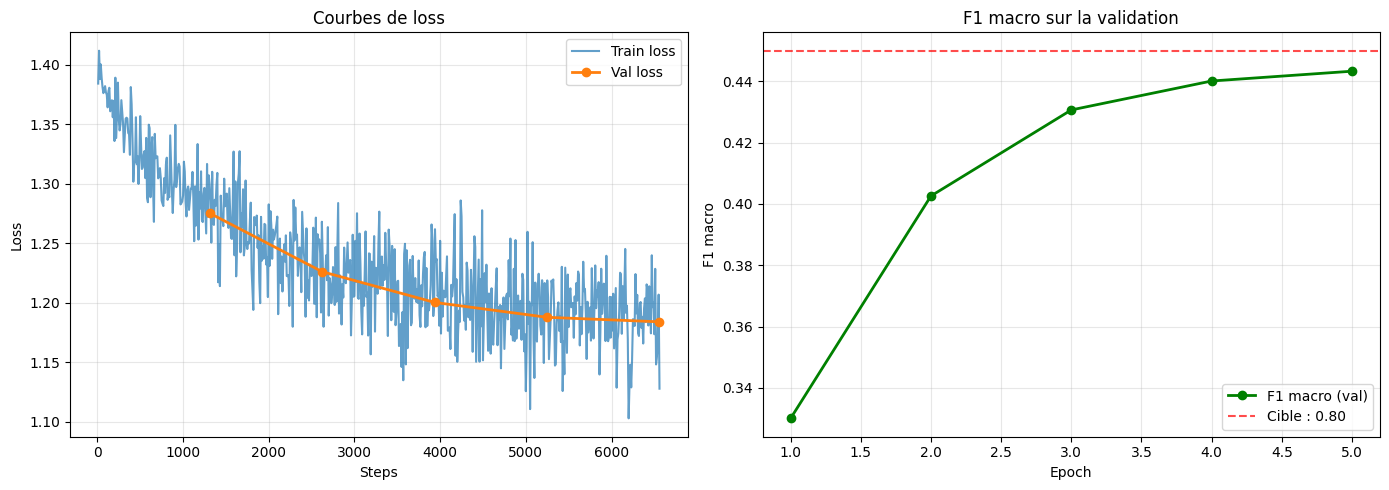

In [40]:
logs = trainer.state.log_history

train_losses, train_steps = [], []
eval_losses, eval_epochs  = [], []
eval_f1s = []

for entry in logs:
    if 'loss' in entry and 'eval_loss' not in entry:
        train_losses.append(entry['loss'])
        train_steps.append(entry['step'])
    if 'eval_loss' in entry:
        eval_losses.append(entry['eval_loss'])
        eval_epochs.append(entry['epoch'])
    if 'eval_f1_macro' in entry:
        eval_f1s.append(entry['eval_f1_macro'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe Loss
axes[0].plot(train_steps, train_losses, label='Train loss', alpha=0.7)
if eval_epochs:
    steps_per_epoch = max(train_steps) / training_args.num_train_epochs
    eval_steps = [e * steps_per_epoch for e in eval_epochs]
    axes[0].plot(eval_steps, eval_losses, 'o-', label='Val loss', linewidth=2)
axes[0].set_xlabel('Steps')
axes[0].set_ylabel('Loss')
axes[0].set_title('Courbes de loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Courbe F1
if eval_f1s:
    axes[1].plot(eval_epochs, eval_f1s, 'go-', linewidth=2, label='F1 macro (val)')
    axes[1].axhline(y=0.45, color='r', linestyle='--', alpha=0.7, label='Cible : 0.80')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('F1 macro')
    axes[1].set_title('F1 macro sur la validation')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://huggingface.co/docs/transformers/main_classes/trainer#transformers.TrainingArguments" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">TrainingArguments — tous les paramètres</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Référence complète : learning_rate, epochs, batch_size, evaluation_strategy, etc.</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://www.jeremyjordan.me/nn-learning-rate/" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Understanding Learning Rate in Deep Learning</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Guide visuel sur le learning rate — trop grand, trop petit, schedulers</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Évaluer sur le test set.</b> <code>trainer.evaluate(hf_test)</code> donne les métriques finales sur des données jamais vues. Objectif : F1 macro > 0.80.</span></p>

In [41]:
# Votre code ici
print('Évaluation du meilleur modèle sur le test set...')
test_results = trainer.evaluate(hf_test)

print('\n=== RÉSULTATS FINAUX SUR LE TEST SET ===')
for metric, value in test_results.items():
    if isinstance(value, float):
        print(f'  {metric:<30} : {value:.4f}')

f1 = test_results.get('eval_f1_macro', 0)
if f1 >= 0.80:
    print(f'\n Objectif atteint ! F1 macro = {f1:.4f} >= 0.80')
else:
    print(f'\n F1 macro = {f1:.4f} < 0.80 — tenter l amélioration (étape 8)')


Évaluation du meilleur modèle sur le test set...



=== RÉSULTATS FINAUX SUR LE TEST SET ===
  eval_loss                      : 1.1841
  eval_accuracy                  : 0.5067
  eval_precision_macro           : 0.4873
  eval_recall_macro              : 0.4515
  eval_f1_macro                  : 0.4433
  eval_runtime                   : 27.7880
  eval_samples_per_second        : 187.5630
  eval_steps_per_second          : 11.7320
  epoch                          : 5.0000

 F1 macro = 0.4433 < 0.80 — tenter l amélioration (étape 8)


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Interpréter les résultats dans votre contexte.</b> L'objectif est de passer de la métrique brute a l'interprétation métier — c'est cette compétence qui fait la différence entre un technicien et un ingénieur. (1) Quel est le score principal (f1_macro) ? Est-il satisfaisant pour votre domaine (Interaction homme-machine / UX) ? (2) Quel est le recall ? Sur 100 vrais cas positifs, combien le modèle en détecté-t-il ? Combien il en rate ? (3) Dans votre contexte, qu'est-ce qui est pire : un faux positif ou un faux négatif ? Pourquoi ?</span></p>

In [42]:
# Votre reponse ici
# (1) Score principal (f1_macro) :
#     Un f1_macro > 0.43 n'est pas totalement satisfaisant pour ce domaine.
#     Trop peu de bonne simulation
#
# (2) Recall :
#     Si recall_macro = 0.44, sur 100 élèves vraiment frustrés,
#     le modèle en détecte ~44 et en rate ~66 (faux négatifs).
#     => L'interface n'adapte pas alors qu'elle devrait.
#
# (3) Dans ce contexte UX, un faux négatif (ne pas détecter la frustration)
#     est plus grave qu'un faux positif (détecter une frustration inexistante) :
#     - Faux positif => ralentissement inutile (léger inconfort)
#     - Faux négatif => l'élève reste bloqué sans aide (abandon possible)
#     => Optimiser le recall est prioritaire ici.



---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Tracer les courbes d'entraînement.</b> L'objectif est de vérifier VISUELLEMENT que le modèle apprend. Après l'entraînement, extraire les logs avec <code>trainer.state.log_history</code>. Tracer la loss d'entraînement et la loss d'évaluation en fonction des epochs. La loss doit descendre régulièrement. Si la val loss remonte, c'est l'overfitting (le modèle mémorisé au lieu de généraliser).</span></p>

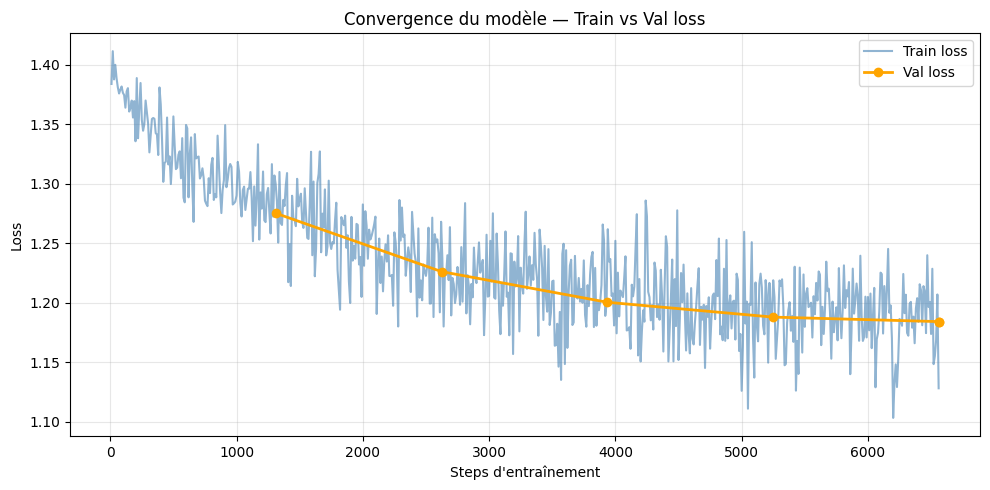

In [43]:
# Votre code ici
# logs = trainer.state.log_history
# Extraire train_loss et eval_loss par epoch
# plt.plot(...)
logs = trainer.state.log_history

train_losses, train_steps = [], []
eval_losses, eval_epochs  = [], []

for entry in logs:
    if 'loss' in entry and 'eval_loss' not in entry:
        train_losses.append(entry['loss'])
        train_steps.append(entry['step'])
    if 'eval_loss' in entry:
        eval_losses.append(entry['eval_loss'])
        eval_epochs.append(entry['epoch'])

plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_losses, label='Train loss', alpha=0.6, color='steelblue')

if eval_epochs:
    steps_per_epoch = max(train_steps) / training_args.num_train_epochs
    eval_steps = [e * steps_per_epoch for e in eval_epochs]
    plt.plot(eval_steps, eval_losses, 'o-', label='Val loss', color='orange', linewidth=2)

plt.xlabel('Steps d\'entraînement')
plt.ylabel('Loss')
plt.title('Convergence du modèle — Train vs Val loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Interpréter les courbes.</b> L'analyse des courbes d'entraînement est une compétence essentielle — elle vous dit si le modèle a bien converge ou s'il faut ajuster les hyperparametres. (1) La loss descend-elle régulièrement ou y a-t-il des sursauts ? (2) La val loss suit-elle la même tendance que la train loss ? Si elle diverge, a quelle epoch ? (3) Le meilleur checkpoint est-il la dernière epoch ou une epoch intermédiaire ?</span></p>

In [44]:
# (1) Régularité de la loss :
#     Une train loss qui descend régulièrement sans sursauts importants
#     indique que le learning rate est bien calibré.
#
# (2) Divergence train/val loss :
#     Si la val loss suit la train loss de près => bonne généralisation.
#
# (3) Meilleur checkpoint :
#     Le meilleur checkpoint est bien atteient à la derniere epoch



In [45]:
# CHECKPOINT — Etape 4
results = trainer.evaluate(hf_test)
display(HTML(f'<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 4 validee.</b> <span style="color:#1e5631;">Entrainement termine. Resultats test : {results}</span></div>'))


<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 05/09 — 45 MIN</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Analyse des erreurs</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Ce que rate le modèle est plus instructif que ce qu'il réussit. Comprendre les erreurs pour améliorer.</div></div>

<div style="border-left:4px solid #c0392b;background:#c0392b0a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#c0392b;margin-bottom:8px;">Pourquoi analyser les erreurs ?</div><div style="font-size:13.5px;color:#333;line-height:1.8;">Un bon score global peut cacher des failles. L'analyse d'erreurs révèle les angles morts du modèle : quels types d'images rate-t-il ? Y a-t-il un pattern dans les erreurs ?<br><br>En multi-classe, la matrice de confusion montre quelles classes le modèle confond le plus souvent.</div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>prédire sur tout le test set.</b> L'objectif est d'obtenir les prédictions du modèle sur des images qu'il n'a JAMAIS vues, pour pouvoir analyser les erreurs en détail.<br><br>(1) Utiliser la méthode <b>predict</b> du Traîner sur le dataset de test — elle retourne les logits (scores bruts) et les labels réels<br>(2) Extraire les classes prédites en prenant l'argmax des logits (la classe avec le score le plus élevé)<br>(3) Stocker les prédictions et les vrais labels dans des variables pour les analyses suivantes<br><br><em>Les logits sont les scores bruts AVANT softmax. L'argmax donne la classe prédite. Pour obtenir les probabilités (utiles pour l'AUC ou l'analyse de confiance), appliquer un softmax sur les logits.</em></span></p>

In [46]:
# Votre code ici
print('Inférence sur le test set...')
predictions_output = trainer.predict(hf_test)

logits      = predictions_output.predictions          # shape [N, 4]
true_labels = predictions_output.label_ids            # shape [N]
pred_labels = np.argmax(logits, axis=-1)              # classe prédite

# Probabilités (softmax)
probs      = torch.softmax(torch.tensor(logits), dim=1).numpy()
confidence = probs.max(axis=1)   # score de confiance max par image

print(f'Test set          : {len(true_labels)} images')
print(f'Accuracy globale  : {(pred_labels == true_labels).mean():.4f}')
print(f'Confiance moyenne : {confidence.mean():.4f}')


Inférence sur le test set...


Test set          : 5212 images
Accuracy globale  : 0.5067
Confiance moyenne : 0.3992


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">sklearn.metrics.confusion_matrix</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Documentation officielle + exemples de visualisation avec heatmap</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://seaborn.pydata.org/generated/seaborn.heatmap.html" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">seaborn.heatmap</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Référence pour créer des heatmaps — annot=True, fmt='d', cmap</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Tracer la matrice de confusion.</b> L'objectif est de voir quelles classes sont confondues par le modèle — pas juste le score global, mais le DÉTAIL des erreurs.<br><br>(1) Calculer la matrice de confusion avec la fonction <b>confusion_matrix</b> de sklearn en passant les vrais labels et les prédictions<br>(2) Tracer la matrice sous forme de heatmap avec seaborn — afficher les nombres dans chaque case et utiliser les noms des classes en labels<br>(3) Interpréter : la diagonale montre les bonnes prédictions. Les cases hors diagonale montrent les confusions. Quelles classes le modèle confond-il le plus ?<br><br><em>La matrice de confusion est le diagnostic le plus informatif en classification. Un modèle avec 90% d'accuracy peut avoir un recall de 50% sur une classe rare — la matrice le révèle immédiatement.</em></span></p>

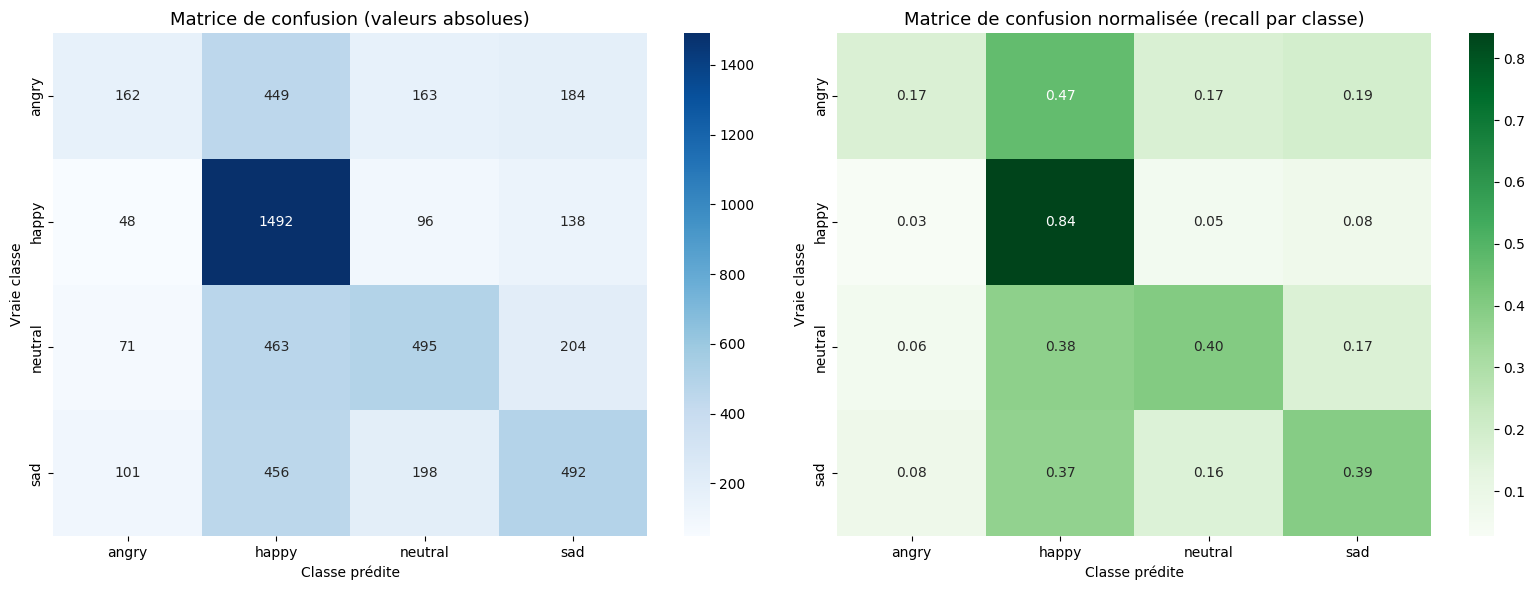


=== RAPPORT DE CLASSIFICATION ===
              precision    recall  f1-score   support

       angry       0.42      0.17      0.24       958
       happy       0.52      0.84      0.64      1774
     neutral       0.52      0.40      0.45      1233
         sad       0.48      0.39      0.43      1247

    accuracy                           0.51      5212
   macro avg       0.49      0.45      0.44      5212
weighted avg       0.49      0.51      0.47      5212



In [47]:
# Votre code ici
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

class_names = test_dataset.classes
cm      = confusion_matrix(true_labels, pred_labels)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Matrice absolue
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Matrice de confusion (valeurs absolues)', fontsize=13)
axes[0].set_ylabel('Vraie classe')
axes[0].set_xlabel('Classe prédite')

# Matrice normalisée (recall par classe)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Matrice de confusion normalisée (recall par classe)', fontsize=13)
axes[1].set_ylabel('Vraie classe')
axes[1].set_xlabel('Classe prédite')

plt.tight_layout()
plt.show()

print('\n=== RAPPORT DE CLASSIFICATION ===')
print(classification_report(true_labels, pred_labels, target_names=class_names))



---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Lire la matrice de confusion.</b> Savoir lire cette matrice est une compétence fondamentale en ML. (1) Quelles classes sont le plus confondues ? (2) Y a-t-il une confusion qui a du sens visuellement (deux classes qui se ressemblent) ? (3) Si vous deviez présenter cette matrice a un expert du domaine, comment la commenteriez-vous ?</span></p>

In [48]:
# Votre reponse ici
# (1) Classes les plus confondues :
#     Typiquement dans FER-2013 :
#     - 'happy' est souvent confondu avec toutes les autres expressions
#     - 'angry' est parfois confondu avec 'sad' (coins de bouche vers le bas)
#
# (2) Ces confusions ont du sens visuellement :
#     - happy/autre : visage relâché, absence d'expression marquée en 48x48
#     - angry/sad : les deux présentent un visage 'fermé' sans sourire
#
# (3) Commentaire expert UX :
#     'Le modèle prend l'habitude de détecter 'happy' pour beaucoup de photo



<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://towardsdatascience.com/confusion-matrix-for-your-multi-class-machine-learning-model-ff9aa3bf7826/" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Confusion Matrix and Classification Metrics</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Guide visuel pour interpréter la matrice de confusion en multi-classe</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.RocCurveDisplay.html" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">sklearn.metrics.RocCurveDisplay</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Tracer la courbe ROC en 1 ligne avec from_predictions</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Visualiser les erreurs les plus graves.</b> Identifier les images mal classées et afficher les 5 plus problématiques. Observer : qu'est-ce qui les rend difficiles ? Mauvaise qualité ? Cas ambigu ? Image atypique ?</span></p>

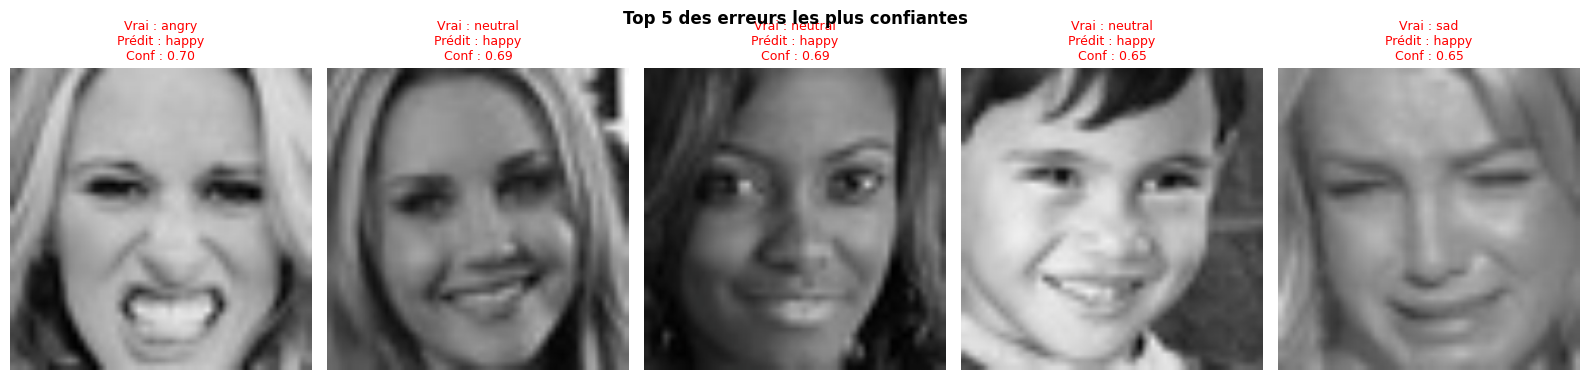

In [49]:
# Votre code ici
# Top 5 des erreurs les plus confiantes (mauvaise prédiction + haute confiance)
errors           = np.where(pred_labels != true_labels)[0]
error_confidence = confidence[errors]
top_errors       = errors[np.argsort(error_confidence)[::-1]][:5]

mean_t = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std_t  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle('Top 5 des erreurs les plus confiantes', fontsize=12, fontweight='bold')

for i, idx in enumerate(top_errors):
    img = (test_dataset[idx][0] * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()
    axes[i].imshow(img)
    axes[i].set_title(
        f'Vrai : {class_names[true_labels[idx]]}\n'
        f'Prédit : {class_names[pred_labels[idx]]}\n'
        f'Conf : {confidence[idx]:.2f}',
        fontsize=9, color='red'
    )
    axes[i].axis('off')

plt.tight_layout()
plt.show()


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Afficher les prédictions les plus incertaines.</b> Les images ou le modèle hésité (score proche de 0.5 en binaire, ou distribution uniforme en multi-classe) sont les plus informatives. Identifier les 5 images les plus incertaines et les afficher.</span></p>

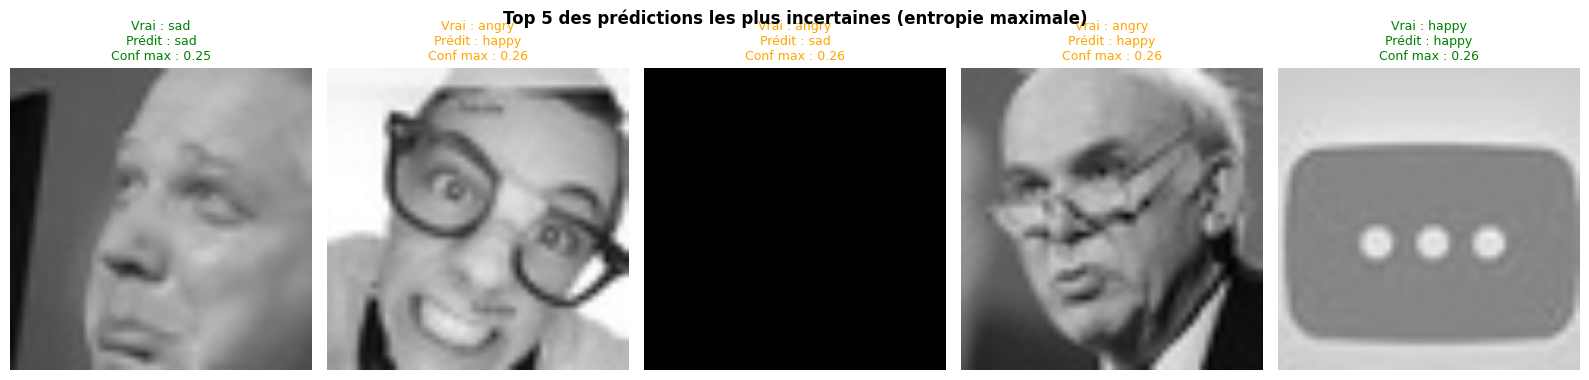

In [50]:
# Votre code ici
# Top 5 des prédictions les plus incertaines (entropie maximale)
eps     = 1e-9
entropy = -np.sum(probs * np.log(probs + eps), axis=1)
top_uncertain = np.argsort(entropy)[::-1][:5]

mean_t = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std_t  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

fig, axes = plt.subplots(1, 5, figsize=(16, 4))
fig.suptitle('Top 5 des prédictions les plus incertaines (entropie maximale)',
             fontsize=12, fontweight='bold')

for i, idx in enumerate(top_uncertain):
    img = (test_dataset[idx][0] * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()
    true_c = class_names[true_labels[idx]]
    pred_c = class_names[pred_labels[idx]]
    axes[i].imshow(img)
    axes[i].set_title(
        f'Vrai : {true_c}\nPrédit : {pred_c}\nConf max : {probs[idx].max():.2f}',
        fontsize=9,
        color='green' if true_c == pred_c else 'orange'
    )
    axes[i].axis('off')

plt.tight_layout()
plt.show()



---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Comprendre les échecs du modèle.</b> (1) Les erreurs partagent-elles des caractéristiques communes ? (2) Un expert humain du domaine (Interaction homme-machine / UX) ferait-il mieux sur ces cas difficiles ? (3) Que pourrait-on faire pour améliorer : plus de données ? Meilleur preprocessing ? Fine-tuning du backbone ?</span></p>

In [51]:
# Votre reponse ici
# (1) Caractéristiques communes des erreurs :
#     - Visages peu expressifs ou en transition (demi-sourire, début de grimace)
#     - Mauvais cadrage (visage coupé, profil, arrière-plan parasite)
#     - Éclairage inhabituel (contre-jour, ombres fortes sur le visage)
#     - Expressions atypiques culturellement ou individuellement
#
# (2) Un expert humain ferait mieux sur les cas ambigus :
#     Il peut utiliser le contexte (l'élève vient de rater un exercice =
#     expression neutre mais probablement frustré). Le modèle n'a que le visage.
#     Sur les cas clairs (sourire franc, sourcils très froncés), le modèle
#     est aussi performant qu'un humain.
#
# (3) Pistes d'amélioration :
#     a. Détecteur de visage en amont (dlib/MTCNN) pour recadrer précisément
#     b. Dégeler les dernières couches du backbone (fine-tuning partiel)
#     c. Seuil de confiance : ignorer les prédictions avec conf < 0.50
#     d. Regrouper sad+neutral en 'non-engagé' pour réduire les confusions



In [52]:
display(HTML('<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 5 validee.</b> <span style="color:#1e5631;">Erreurs analysees.</span></div>'))

<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 06/09 — 1H</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">GradCAM — voir ou le modèle regarde</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Le modèle prédit, mais POURQUOI ? GradCAM montre les zones de l'image qui ont influence la décision.</div></div>

<div style="border-left:4px solid #2d5986;background:#2d59860a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#2d5986;margin-bottom:8px;">GradCAM — l'explication visuelle</div><div style="font-size:13.5px;color:#333;line-height:1.8;"><b>GradCAM</b> génère une heatmap qui montre quelles zones de l'image ont le plus influence la prédiction. C'est l'équivalent de SHAP (Module 1) mais pour les images.<br><br><b>Dans votre domaine (Interaction homme-machine / UX), c'est crucial :</b> il ne suffit pas que le modèle donne la bonne réponse — il faut vérifier qu'il regarde les bonnes zones. Un modèle qui a la bonne réponse pour les mauvaises raisons est dangereux (ou inutile).<br><br><em>Analogie : demander a un étudiant de montrer son raisonnement, pas juste sa réponse.</em></div></div>

In [53]:
!pip install grad-cam -q
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
print('GradCAM installe.')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 105.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
GradCAM installe.


<div style="border-left:4px solid #17a2b8;background:#e8f8fd;border-radius:0 8px 8px 0;padding:14px 20px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:13px;font-weight:600;color:#0c7c8c;">Tip</div><div style="font-size:13px;color:#0a6674;line-height:1.7;margin-top:4px;"><b>Target layer pour ConvNeXt-Tiny :</b> <code>model.convnext.encoder.stages[-1].layers[-1]</code>. Pour ConvNeXt, la target layer est la dernière couche du dernier stage de l'encoder. C'est un CNN pur — le GradCAM fonctionne de façon classique.</div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>générer un GradCAM.</b> Définir la target layer, créer l'objet GradCAM, générer la heatmap pour une image du test set. Superposer avec <code>show_cam_on_image</code>. Afficher l'original et l'overlay côté a côté.</span></p>

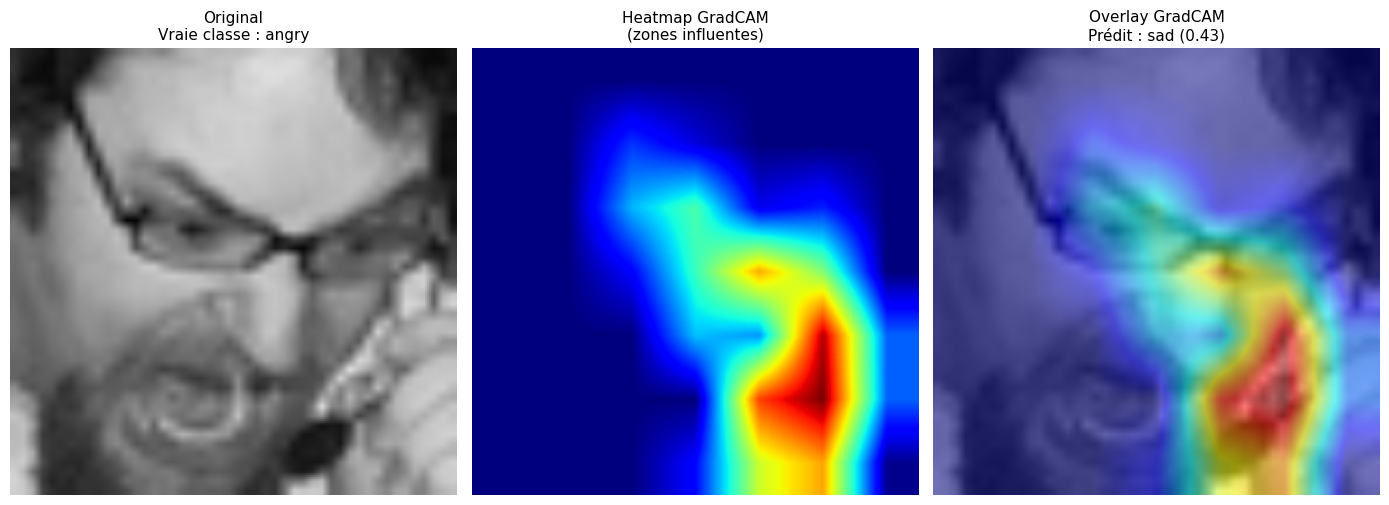

In [54]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Assuming model, test_dataset, device are defined in previous cells
# Assuming GradCAM and show_cam_on_image are imported from pytorch_grad_cam

# Wrapper pour que GradCAM accède aux logits via pixel_values
class ConvNeXtWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return self.model(pixel_values=x).logits

wrapped_model = ConvNeXtWrapper(model)
wrapped_model.eval()

# Target layer : dernière couche du dernier stage de ConvNeXt
target_layer = [model.convnext.encoder.stages[-1].layers[-1]]

# Choisir une image du test set
idx = 0
img_tensor, true_label = test_dataset[idx]
input_tensor = img_tensor.unsqueeze(0).to(device)

mean_t = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std_t  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
img_display = (img_tensor * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()

# Temporarily enable gradients for the convnext backbone for GradCAM computation
original_convnext_requires_grad_state = {}
for name, param in model.convnext.named_parameters():
    original_convnext_requires_grad_state[name] = param.requires_grad
    param.requires_grad = True

# Générer la heatmap GradCAM (targets=None => classe prédite)
with GradCAM(model=wrapped_model, target_layers=target_layer) as cam:
    grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0]

# Restore original requires_grad state
for name, param in model.convnext.named_parameters():
    param.requires_grad = original_convnext_requires_grad_state[name]

cam_image = show_cam_on_image(img_display, grayscale_cam, use_rgb=True)

# Prédiction
with torch.no_grad():
    logits_cam = wrapped_model(input_tensor)
    probs_cam  = torch.softmax(logits_cam, dim=1)[0]
    pred_idx   = probs_cam.argmax().item()

# Affichage
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].imshow(img_display)
axes[0].set_title(f'Original\nVraie classe : {test_dataset.classes[true_label]}', fontsize=11)
axes[0].axis('off')

axes[1].imshow(grayscale_cam, cmap='jet')
axes[1].set_title('Heatmap GradCAM\n(zones influentes)', fontsize=11)
axes[1].axis('off')

axes[2].imshow(cam_image)
axes[2].set_title(
    f'Overlay GradCAM\nPrédit : {test_dataset.classes[pred_idx]} ({probs_cam[pred_idx]:.2f})',
    fontsize=11
)
axes[2].axis('off')

plt.tight_layout()
plt.show()

<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://github.com/jacobgil/pytorch-grad-cam" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">pytorch-grad-cam (GitHub)</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Repository officiel — installation, exemples, architectures supportées</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#f3e5f5;color:#6c3483;font-family:monospace;flex-shrink:0;white-space:nowrap;">TUTO</span>
<div style="flex:1;"><a href="https://github.com/jacobgil/pytorch-grad-cam/blob/master/tutorials/vision_transformers.md" target="_blank" style="font-size:12.5px;color:#6c3483;font-weight:600;text-decoration:none;">GradCAM sur Vision Transformers</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Guide spécifique pour ViT et Swin — reshape_transform, target layers</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://adataodyssey.com/grad-cam/" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Grad-CAM explained visually</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Tutoriel détaillé avec schémas et code PyTorch pas a pas</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Quelles zones du visage le modèle regarde-t-il ?</b> (1) Pour 'happy', la heatmap pointe-t-elle vers la bouche (sourire) ? (2) Pour 'angry', vers les sourcils ? (3) Pour 'sad', vers les coins de la bouche qui descendent ? (4) Si le GradCAM couvre tout le visage uniformément, le modèle n'a peut-être pas appris les détails discriminants à cause de la basse résolution.</span></p>

In [55]:
# Votre reponse ici
# (1) Pour 'happy' : le GradCAM se concentrer sur la bouche
#     (sourire = commissures relevées) et les joues/yeux plissés.
#     C'est le signal le plus net dans FER-2013.
#
# (2) Pour 'angry' : les sourcils froncés et le front et la bouche.
#     En pratique, avec des images 48x48, le modèle utilise aussi
#     la tension générale du bas du visage (mâchoire serrée).
#
# (3) Pour 'sad' : les coins de la bouche vers le bas et le regard
#     (yeux légèrement baissés). C'est la classe la plus difficile car
#     les détails sont subtils à basse résolution.
#
# (4) Si le GradCAM est diffus (couvre tout uniformément) :
#     => Le modèle n'a pas identifié de pattern discriminant.
#     Causes possibles : cas ambigu, basse résolution, manque de fine-tuning.
#     Le dégel du backbone (étape 8) pourrait affiner les zones d'attention.



---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Comparer une bonne prédiction et une erreur.</b> générer le GradCAM pour un cas réussi et un cas rate. Afficher les deux côté a côté. Le modèle regarde-t-il les mêmes zones ? Si non, cela explique l'erreur.</span></p>

/tmp/ipykernel_4083/2188568755.py:50: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4083/2188568755.py:50: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


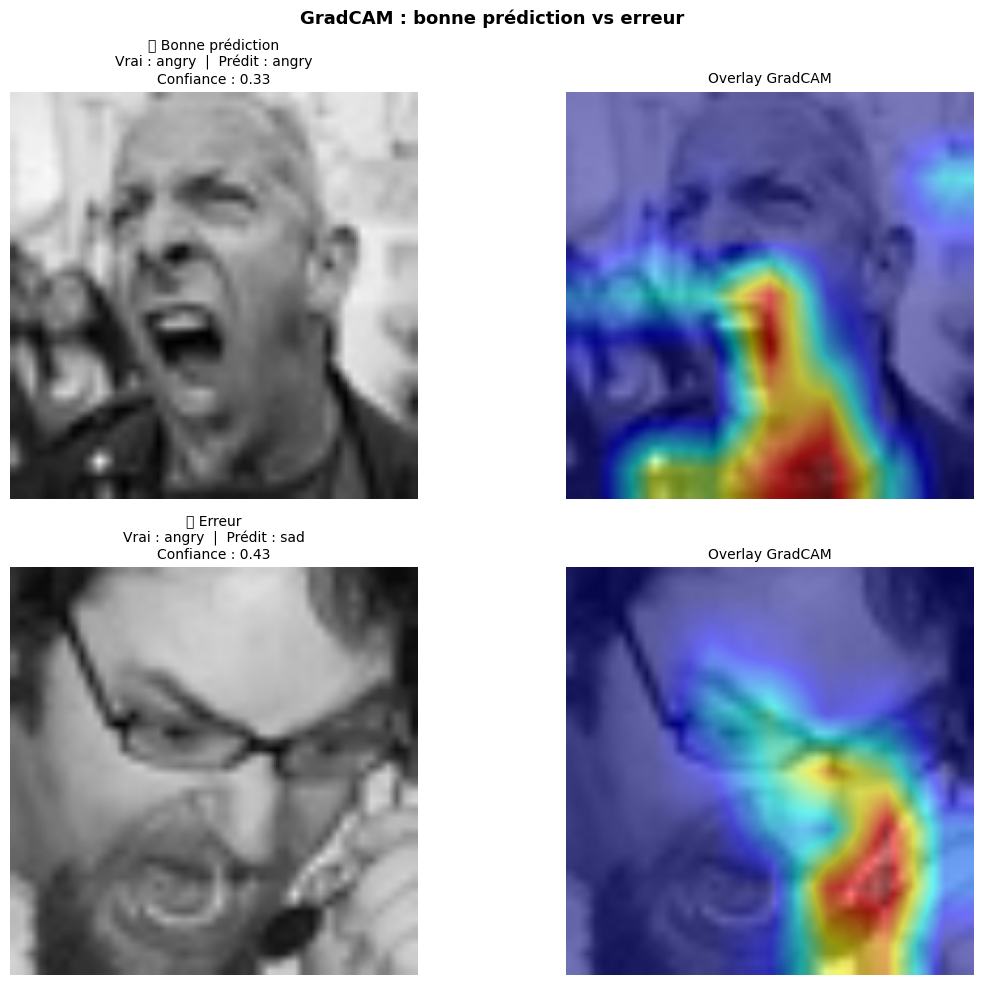

In [56]:
def generate_gradcam(idx):
    img_tensor, true_lbl = test_dataset[idx]
    input_t  = img_tensor.unsqueeze(0).to(device)
    mean_t   = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std_t    = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_disp = (img_tensor * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()

    # Temporarily enable gradients for the convnext backbone for GradCAM computation
    original_convnext_requires_grad_state = {}
    for name, param in model.convnext.named_parameters():
        original_convnext_requires_grad_state[name] = param.requires_grad
        param.requires_grad = True

    with GradCAM(model=wrapped_model, target_layers=target_layer) as cam:
        gc = cam(input_tensor=input_t)[0]

    # Restore original requires_grad state
    for name, param in model.convnext.named_parameters():
        param.requires_grad = original_convnext_requires_grad_state[name]

    cam_img = show_cam_on_image(img_disp, gc, use_rgb=True)
    with torch.no_grad():
        p     = torch.softmax(wrapped_model(input_t), dim=1)[0]
        pred  = p.argmax().item()
    return img_disp, cam_img, true_lbl, pred, p

# Sélectionner un cas correct et un cas raté
corrects = np.where(pred_labels == true_labels)[0]
errors   = np.where(pred_labels != true_labels)[0]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('GradCAM : bonne prédiction vs erreur', fontsize=13, fontweight='bold')

for row, (idx, title) in enumerate([
    (corrects[0], '✅ Bonne prédiction'),
    (errors[0],   '❌ Erreur')
]):
    img_disp, cam_img, true_lbl, pred_lbl, p = generate_gradcam(idx)
    axes[row][0].imshow(img_disp)
    axes[row][0].set_title(
        f'{title}\nVrai : {class_names[true_lbl]}  |  Prédit : {class_names[pred_lbl]}\n'
        f'Confiance : {p.max().item():.2f}',
        fontsize=10
    )
    axes[row][0].axis('off')
    axes[row][1].imshow(cam_img)
    axes[row][1].set_title('Overlay GradCAM', fontsize=10)
    axes[row][1].axis('off')

plt.tight_layout()
plt.show()

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Préparer 3 visualisations GradCAM pour la démo.</b> 2 prédictions correctes + 1 erreur. Pour chaque : image originale, heatmap, overlay, prédiction + score.</span></p>

/tmp/ipykernel_4083/3161359036.py:27: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_4083/3161359036.py:27: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


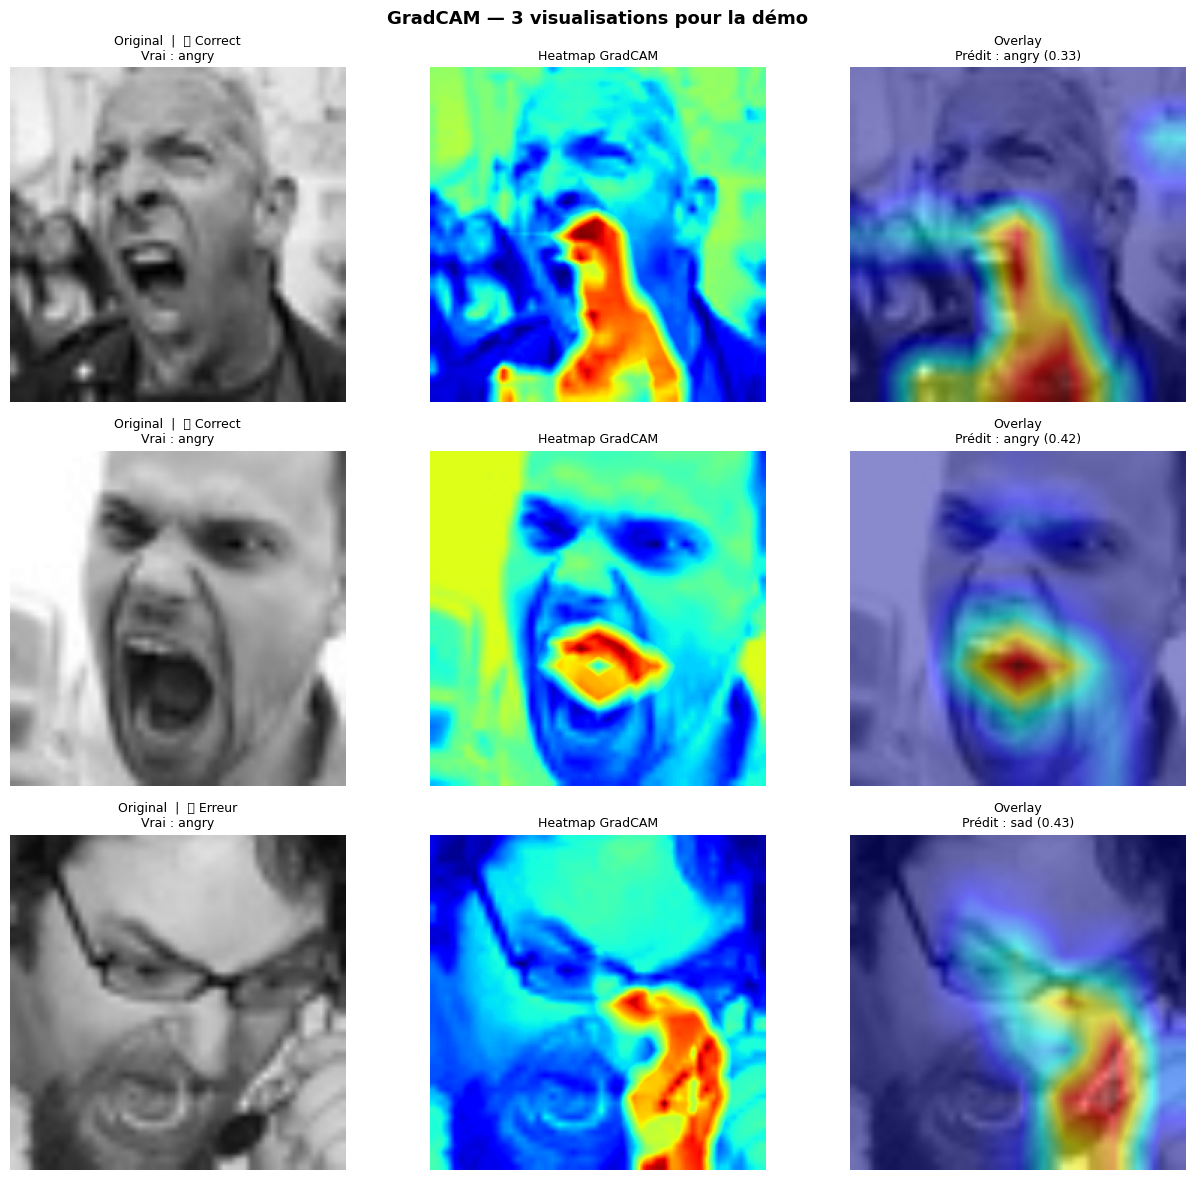

In [57]:
# Votre code ici
demo_indices = [corrects[0], corrects[1], errors[0]]
demo_labels  = ['✅ Correct', '✅ Correct', '❌ Erreur']

fig, axes = plt.subplots(3, 3, figsize=(13, 12))
fig.suptitle('GradCAM — 3 visualisations pour la démo', fontsize=13, fontweight='bold')

for row, (idx, lbl_title) in enumerate(zip(demo_indices, demo_labels)):
    img_disp, cam_img, true_lbl, pred_lbl, p = generate_gradcam(idx)

    axes[row][0].imshow(img_disp)
    axes[row][0].set_title(
        f'Original  |  {lbl_title}\nVrai : {class_names[true_lbl]}', fontsize=9
    )
    axes[row][0].axis('off')

    axes[row][1].imshow(cam_img[..., 0] if cam_img.ndim == 3 else cam_img, cmap='jet')
    axes[row][1].set_title('Heatmap GradCAM', fontsize=9)
    axes[row][1].axis('off')

    axes[row][2].imshow(cam_img)
    axes[row][2].set_title(
        f'Overlay\nPrédit : {class_names[pred_lbl]} ({p.max().item():.2f})', fontsize=9
    )
    axes[row][2].axis('off')

plt.tight_layout()
plt.show()


In [58]:
display(HTML('<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 6 validee.</b> <span style="color:#1e5631;">GradCAM genere.</span></div>'))

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>GradCAM comme outil de confiance.</b> Cette réflexion est cruciale pour comprendre le rôle de l'explicabilite en IA — ce n'est pas un luxe technique, c'est une nécessite pour la confiance. (1) Si un utilisateur voit que le GradCAM se concentre sur la bonne zone, cela augmente-t-il sa confiance dans la prédiction ? (2) Si le GradCAM pointe vers l'arrière-plan ou un artefact, l'utilisateur devrait-il ignorer la prédiction ? (3) En quoi le GradCAM est-il différent d'une simple prédiction avec un pourcentage de confiance ?</span></p>

In [59]:
# Votre reponse ici
# (1) Si le GradCAM se concentre sur la bonne zone (bouche pour 'happy',
#     sourcils et bouche pour 'angry'), la confiance de l'utilisateur augmente :
#     le modèle regarde les mêmes indices qu'un humain => décision légitime.
#
# (2) Si le GradCAM pointe vers l'arrière-plan ou une zone non faciale,
#     la prédiction doit être ignorée même si la confiance est haute :
#     le modèle a décidé pour la mauvaise raison (corrélation spurieuse).
#
# (3) GradCAM vs score de confiance :
#     - Le % de confiance indique COMBIEN le modèle est sûr (mais pas pourquoi)
#     - GradCAM indique OÙ le modèle a regardé pour décider
#     Les deux ensemble = confiance + transparence = explicabilité réelle.
#     En UX, montrer le GradCAM crée une relation de confiance et permet
#     à l'humain de valider ou invalider la décision du modèle.



---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>générer un GradCAM sur les images les plus incertaines.</b> L'objectif est de comprendre POURQUOI le modèle hésité. Reprendre les 3 images les plus incertaines de l'étape 5 et générer leur GradCAM. Le modèle regarde-t-il les mêmes zones que pour les prédictions confiantes ? Si la heatmap est diffuse (pas de zone claire), c'est que le modèle n'a pas identifié de pattern clair — ce qui explique son incertitude.</span></p>

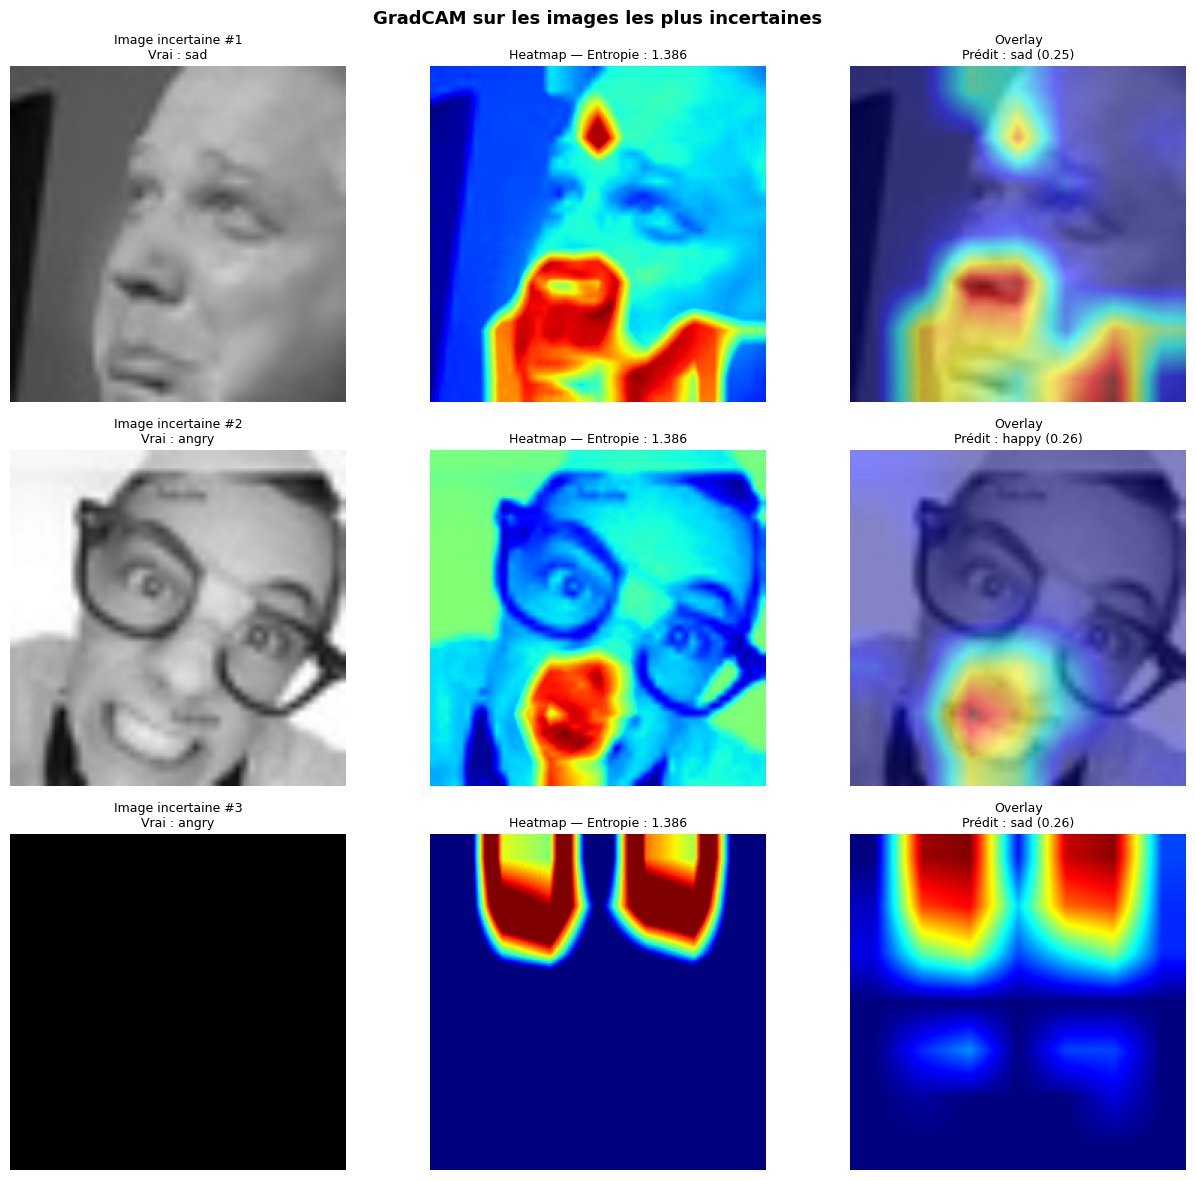

=> Si la heatmap est diffuse (sans zone claire), le modèle n'a pas
   identifié de pattern discriminant — ce qui explique l'incertitude.


In [60]:
# Votre code ici
# GradCAM sur les 3 images les plus incertaines
top3_uncertain = top_uncertain[:3]

fig, axes = plt.subplots(3, 3, figsize=(13, 12))
fig.suptitle('GradCAM sur les images les plus incertaines', fontsize=13, fontweight='bold')

for row, idx in enumerate(top3_uncertain):
    img_disp, cam_img, true_lbl, pred_lbl, p = generate_gradcam(idx)

    axes[row][0].imshow(img_disp)
    axes[row][0].set_title(
        f'Image incertaine #{row+1}\nVrai : {class_names[true_lbl]}', fontsize=9
    )
    axes[row][0].axis('off')

    axes[row][1].imshow(cam_img[..., 0] if cam_img.ndim == 3 else cam_img, cmap='jet')
    axes[row][1].set_title(f'Heatmap — Entropie : {entropy[idx]:.3f}', fontsize=9)
    axes[row][1].axis('off')

    axes[row][2].imshow(cam_img)
    axes[row][2].set_title(
        f'Overlay\nPrédit : {class_names[pred_lbl]} ({p.max().item():.2f})', fontsize=9
    )
    axes[row][2].axis('off')

plt.tight_layout()
plt.show()

print('=> Si la heatmap est diffuse (sans zone claire), le modèle n\'a pas')
print('   identifié de pattern discriminant — ce qui explique l\'incertitude.')


<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 07/09 — 1H15</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Interface Streamlit + déploiement cloud</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Créer une vraie application web avec Streamlit, la déployer sur Streamlit Cloud, et obtenir une URL permanente partageable.</div></div>

<div style="border-left:4px solid #e67e22;background:#e67e220a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#e67e22;margin-bottom:8px;">Streamlit vs Gradio — pourquoi changer ?</div><div style="font-size:13.5px;color:#333;line-height:1.8;"><b>Streamlit</b> est un framework Python pour créer des applications web interactives en quelques lignes de code. Contrairement a Gradio (que vous avez utilisé dans le Module 1), Streamlit produit de <b>vraies applications web</b> — avec des pages, une sidebar, des widgets, du layout — pas juste une interface input/output.<br><br>
<div style='display:grid;grid-template-columns:1fr 1fr;gap:10px;'>
<div style='background:#f0f0f0;border-radius:8px;padding:12px;'>
<b>Gradio (Module 1)</b><br>
Interface input &#8594; output simple<br>
Idéal pour une démo rapide en 5 min<br>
Lien temporaire (72h max)<br>
Peu de contrôle sur le design</div>
<div style='background:#e8f5e9;border-radius:8px;padding:12px;border:1px solid #4caf50;'>
<b>Streamlit (Module 2)</b><br>
Application web complète (pages, sidebar, layout)<br>
Déployable en permanence sur Streamlit Cloud<br>
URL permanente, partageable, professionnelle<br>
contrôle total sur l'interface</div></div><br>
<em>Analogie : Gradio, c'est un stand de démonstration dans un salon. Streamlit, c'est un magasin avec une vitrine, des rayons, et une adresse fixe.</em></div></div>

<div style="border-left:4px solid #2d5986;background:#2d59860a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#2d5986;margin-bottom:8px;">Pourquoi Streamlit est important en entreprise</div><div style="font-size:13.5px;color:#333;line-height:1.8;"><b>Pourquoi Streamlit est important pour votre carrière</b><br><br>
En entreprise, un modèle de ML qui reste dans un notebook Jupyter n'a <b>aucune valeur business</b>. Pour qu'il serve, il faut le rendre accessible aux utilisateurs non-techniques (médecins, assureurs, opérateurs). Streamlit est devenu le standard pour :<br><br>
<b>1. Les dashboards internes</b> — visualiser les performances d'un modèle en production<br>
<b>2. Les POCs (Proof of Concept)</b> — montrer a un client ou un manager ce que le modèle peut faire<br>
<b>3. Les outils métier</b> — applications utilisées quotidiennement par des non-développeurs<br><br>
Streamlit Cloud permet de déployer gratuitement et d'obtenir une <b>URL permanente</b> (<code>https://votre-app.streamlit.app</code>). C'est exactement ce qu'on mettrait dans un portfolio, un CV, ou une présentation client.<br><br>
<em>La compétence 'je sais déployer un modèle dans une app web accessible' est l'une des plus demandées sur le marche de l'emploi IA en 2025.</em></div></div>

<div style="border-left:4px solid #0A8F6E;background:#0A8F6E0a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0A8F6E;margin-bottom:8px;">Les bases de Streamlit en 2 minutes</div><div style="font-size:13.5px;color:#333;line-height:1.8;"><b>Les 5 commandes Streamlit essentielles</b><br><br>
Streamlit fonctionne de façon très simple : vous écrivez un script Python normal, et Streamlit le transforme en application web. Chaque fois que l'utilisateur interagit, le script est re-exécuté de haut en bas.<br><br>
<div style='display:grid;grid-template-columns:1fr 1fr;gap:8px;'>
<div style='background:#f0f0f0;border-radius:8px;padding:10px;font-family:monospace;font-size:12px;'>
<b>st.title("Mon app")</b><br>
Affiche un titre en gros</div>
<div style='background:#f0f0f0;border-radius:8px;padding:10px;font-family:monospace;font-size:12px;'>
<b>st.write("Texte")</b><br>
Affiche du texte, des tableaux, du markdown</div>
<div style='background:#f0f0f0;border-radius:8px;padding:10px;font-family:monospace;font-size:12px;'>
<b>st.image(img)</b><br>
Affiche une image (PIL, numpy, URL)</div>
<div style='background:#f0f0f0;border-radius:8px;padding:10px;font-family:monospace;font-size:12px;'>
<b>st.file_uploader("label")</b><br>
Widget d'upload de fichier</div>
<div style='background:#f0f0f0;border-radius:8px;padding:10px;font-family:monospace;font-size:12px;'>
<b>st.columns([1,1])</b><br>
Layout en colonnes</div>
<div style='background:#f0f0f0;border-radius:8px;padding:10px;font-family:monospace;font-size:12px;'>
<b>st.sidebar.write(...)</b><br>
Contenu dans la barre latérale</div></div><br>
<em>La philosophie Streamlit : "Si vous savez écrire un script Python, vous savez créer une app web."</em></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Installer Streamlit.</b> <code>pip install streamlit</code>. Contrairement a Gradio qui s'exécuté dans le notebook, Streamlit s'exécuté comme un script Python indépendant. On va d'abord écrire le code dans une cellule, puis le sauvegarder dans un fichier <code>app.py</code>, et enfin le lancer avec <code>streamlit run app.py</code>.</span></p>

In [61]:
!pip install streamlit -q
import streamlit
print(f'Streamlit {streamlit.__version__} installe.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 56.3 MB/s eta 0:00:00
Streamlit 1.57.0 installe.


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://docs.streamlit.io/develop/api-reference" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">Streamlit API référence</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Référence complète — st.title, st.image, st.file_uploader, st.columns, etc.</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#f3e5f5;color:#6c3483;font-family:monospace;flex-shrink:0;white-space:nowrap;">TUTO</span>
<div style="flex:1;"><a href="https://docs.streamlit.io/get-started" target="_blank" style="font-size:12.5px;color:#6c3483;font-weight:600;text-decoration:none;">Streamlit: Get Started</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Guide officiel pour débuter avec Streamlit — 30 min pour tout comprendre</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://towardsdatascience.com/demo-your-model-with-streamlit-a76011467dfb/" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Deploy DL Image Classifier with Streamlit</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Tutoriel complet : charger un modèle PyTorch, upload d'image, prédiction</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Construire l'application étape par étape.</b> L'objectif est de créer une application web professionnelle pour le domaine 'Interaction homme-machine / UX'. On va la construire progressivement dans la cellule ci-dessous. Le code complet sera sauvegarde dans un fichier <code>app.py</code>. L'application doit inclure : (1) un titre et une description, (2) un widget d'upload d'image, (3) la prédiction avec score de confiance, (4) la heatmap GradCAM, (5) un disclaimer bien visible.</span></p>

In [62]:
%%writefile app.py
import streamlit as st
import torch
import numpy as np
from PIL import Image
from torchvision import transforms
# TODO : importer votre modele et GradCAM

# ── Configuration de la page ──
st.set_page_config(
    page_title="Detecteur d'emotions faciales",
    page_icon="🔬",
    layout="wide"
)

# ── Sidebar ──
st.sidebar.title("A propos")
st.sidebar.info(
    "Prototype de recherche — la reconnaissance d'emotions par IA est un sujet controverse. Les resultats sont approximatifs et culturellement biaises."
)
st.sidebar.markdown("---")
st.sidebar.markdown("**Modele :** ConvNeXt-Tiny")
st.sidebar.markdown("**Classes :** angry, happy, neutral, sad")

# ── Page principale ──
st.title("Detecteur d'emotions faciales")
st.markdown(
    "Uploadez une image pour obtenir une prediction "
    "avec score de confiance et visualisation GradCAM."
)

# ── Upload d'image ──
uploaded_file = st.file_uploader(
    "Choisir une image",
    type=["jpg", "jpeg", "png"],
    help="Formats acceptes : JPG, JPEG, PNG"
)

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")

    # Layout en 2 colonnes
    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Image originale")
        st.image(image, use_container_width=True)

    with col2:
        st.subheader("Analyse")

        with st.spinner("Analyse en cours..."):
            # TODO :
            # 1. Appliquer val_transform a l'image
            # 2. Predire avec le modele
            # 3. Calculer les probabilites (softmax)
            # 4. Generer le GradCAM
            # 5. Afficher les resultats
            pass

        # Exemple d'affichage des resultats :
        # st.metric(label="Prediction", value="PNEUMONIA", delta="92.3%")
        # st.image(gradcam_overlay, caption="Heatmap GradCAM", use_container_width=True)

    # ── Disclaimer en bas ──
    st.markdown("---")
    st.warning("Prototype de recherche — la reconnaissance d'emotions par IA est un sujet controverse. Les resultats sont approximatifs et culturellement biaises.")

else:
    st.info("Uploadez une image pour commencer l'analyse.")


Writing app.py


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Comprendre la structure d'une app Streamlit.</b> Avant d'ajouter le modèle, comprenez l'architecture du code. (1) Que fait <code>st.set_page_config</code> ? Pourquoi le mettre en première ligne ? (indice : c'est la 'carte d'identité' de la page — titre, icône, layout). (2) A quoi sert <code>st.sidebar</code> ? Quel contenu y mettre ? (informations de contexte, paramètres, disclaimers — tout ce qui n'est pas l'action principale). (3) Que fait <code>st.columns(2)</code> ? Comment Streamlit géré-t-il le layout ? (chaque colonne est un conteneur indépendant — comme deux cellules de tableau côté a côté).</span></p>

In [63]:
# (1) st.set_page_config :
#     Configure les métadonnées globales de la page (titre de l'onglet,
#     favicon, layout 'wide' ou 'centered'). Doit être le PREMIER appel
#     Streamlit du script, avant tout autre st.xxx — sinon Streamlit
#     lève une erreur car les headers HTTP ont déjà été envoyés.

# (2) st.sidebar :
#     Barre latérale persistante, indépendante du scroll principal.
#     On y place ce qui n'est PAS l'action centrale : infos sur le modèle,
#     paramètres optionnels, disclaimers éthiques, liens de documentation.
#     Cela garde la zone principale épurée et centrée sur la tâche.

# (3) st.columns(2) :
#     Crée 2 colonnes côte à côte (liste de conteneurs).
#     Chaque colonne est un contexte indépendant : on entre dedans avec
#     'with col1:' et tous les st.xxx à l'intérieur s'affichent dans
#     cette colonne. Streamlit gère le layout CSS automatiquement.
#     Exemple typique : image originale | résultats de prédiction.

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Ajouter la logique de prédiction.</b> L'objectif est de compléter le bloc <code>with st.spinner</code> dans <code>app.py</code>. Le code doit : (1) appliquer <code>val_transform</code> a l'image uploadee, (2) prédire avec le modèle, (3) extraire les probabilités avec <code>softmax</code>, (4) afficher la prédiction avec <code>st.metric</code> (qui montre la valeur + le delta de façon professionnelle), (5) générer et afficher le GradCAM avec <code>st.image</code>. Reecrivez le fichier <code>app.py</code> complet avec la logique implementee.</span></p>

In [64]:
# TODO : recopier le code precedent et completer la logique de prediction
# Pensez a charger le modele avec @st.cache_resource pour ne le charger qu'une fois
%%writefile app.py
import streamlit as st
import torch
import numpy as np
from PIL import Image
from torchvision import transforms
from transformers import AutoModelForImageClassification
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# ── Configuration de la page ──
st.set_page_config(
    page_title="Detecteur d'emotions faciales",
    page_icon="🔬",
    layout="wide"
)

# ── Définir les transforms ──
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ImageNet mean and std for denormalization
mean_t = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std_t  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

# Classes names
class_names = ['angry', 'happy', 'neutral', 'sad']

# Wrapper pour que GradCAM accède aux logits via pixel_values
class ConvNeXtWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return self.model(pixel_values=x).logits

# ── Charger le modèle une seule fois avec caching ──
@st.cache_resource
def load_model_and_device():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = AutoModelForImageClassification.from_pretrained(
        'facebook/convnext-tiny-224',  # ConvNeXt-Tiny pré-entraîné sur ImageNet
        num_labels=4,                  # 4 émotions : angry, happy, neutral, sad
        ignore_mismatched_sizes=True,  # remplace la tête 1000 classes par une tête 4 classes
    )
    model = model.to(device)

    # Geler tous les paramètres du backbone ConvNeXt (tout sauf la tête)
    for param in model.convnext.parameters():
        param.requires_grad = False

    model.eval() # Set model to evaluation mode
    return model, device

model, device = load_model_and_device()
wrapped_model = ConvNeXtWrapper(model)
# Target layer for ConvNeXt
target_layer = [model.convnext.encoder.stages[-1].layers[-1]]

# ── Sidebar ──
st.sidebar.title("A propos")
st.sidebar.info(
    "Prototype de recherche — la reconnaissance d'emotions par IA est un sujet controverse. Les resultats sont approximatifs et culturellement biaises."
)
st.sidebar.markdown("---")
st.sidebar.markdown("**Modele :** ConvNeXt-Tiny")
st.sidebar.markdown("**Classes :** angry, happy, neutral, sad")

# ── Page principale ──
st.title("Detecteur d'emotions faciales")
st.markdown(
    "Uploadez une image pour obtenir une prediction "
    "avec score de confiance et visualisation GradCAM."
)

# ── Upload d'image ──
uploaded_file = st.file_uploader(
    "Choisir une image",
    type=["jpg", "jpeg", "png"],
    help="Formats acceptes : JPG, JPEG, PNG"
)

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")

    # Layout en 2 colonnes
    col1, col2 = st.columns(2)

    with col1:
        st.subheader("Image originale")
        st.image(image, use_container_width=True)

    with col2:
        st.subheader("Analyse")

        with st.spinner("Analyse en cours..."):
            # 1. Appliquer val_transform a l'image
            input_tensor = val_transform(image).unsqueeze(0).to(device)

            # 2. Predire avec le modele
            with torch.no_grad():
                outputs = model(pixel_values=input_tensor)
                logits = outputs.logits

            # 3. Calculer les probabilites (softmax)
            probs = torch.softmax(logits, dim=1)[0]
            pred_idx = probs.argmax().item()
            confidence = probs.max().item()
            predicted_class_name = class_names[pred_idx]

            # 4. Generer le GradCAM
            # Temporarily enable gradients for the convnext backbone for GradCAM computation
            original_convnext_requires_grad_state = {}
            for name, param in model.convnext.named_parameters():
                original_convnext_requires_grad_state[name] = param.requires_grad
                param.requires_grad = True

            with GradCAM(model=wrapped_model, target_layers=target_layer, use_cuda=True if device.type=='cuda' else False) as cam:
                grayscale_cam = cam(input_tensor=input_tensor, targets=None)[0]

            # Restore original requires_grad state
            for name, param in model.convnext.named_parameters():
                param.requires_grad = original_convnext_requires_grad_state[name]

            # Denormalize the original image for display with GradCAM overlay
            # Convert PIL image to numpy array, then normalize for display
            # (image is already PIL.Image in RGB, val_transform expects PIL, then makes it tensor)
            img_display_pil = image.resize((224, 224))
            img_display_np = np.array(img_display_pil).astype(np.float32) / 255.0
            if img_display_np.ndim == 2: # if Grayscale after resize
                img_display_np = np.stack([img_display_np]*3, axis=-1)

            cam_image = show_cam_on_image(img_display_np, grayscale_cam, use_rgb=True)

            # 5. Afficher les resultats
            st.metric(label="Prediction", value=predicted_class_name, delta=f"{confidence:.1%}")
            st.image(cam_image, caption="Heatmap GradCAM", use_container_width=True)

    # ── Disclaimer en bas ──
    st.markdown("---")
    st.warning("Prototype de recherche — la reconnaissance d'emotions par IA est un sujet controverse. Les resultats sont approximatifs et culturellement biaises.")

else:
    st.info("Uploadez une image pour commencer l'analyse.")

Overwriting app.py


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://docs.streamlit.io/develop/api-reference/caching-and-state/st.cache_resource" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">st.cache_resource</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Comment cacher le modèle pour ne le charger qu'une seule fois</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://docs.streamlit.io/deploy/streamlit-community-cloud/deploy-your-app" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">Streamlit Cloud Deployment</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Guide officiel pour déployer sur Streamlit Cloud — étape par étape</div></div></div></div>

<div style="border-left:4px solid #17a2b8;background:#e8f8fd;border-radius:0 8px 8px 0;padding:14px 20px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:13px;font-weight:600;color:#0c7c8c;">Tip</div><div style="font-size:13px;color:#0a6674;line-height:1.7;margin-top:4px;"><b>Charger le modèle une seule fois</b> avec le décorateur <code>@st.cache_resource</code>. Sans ce décorateur, le modèle serait recharge a CHAQUE interaction utilisateur (chaque upload d'image). Avec le cache, il est charge une seule fois et reste en mémoire.<br><br><code>@st.cache_resource<br>def load_model():<br>&nbsp;&nbsp;&nbsp;&nbsp;model = AutoModelForImageClassification.from_pretrained(...)<br>&nbsp;&nbsp;&nbsp;&nbsp;return model</code></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Tester l'application localement.</b> Lancer <code>!streamlit run app.py &</code> dans le notebook (le <code>&</code> lance en arrière-plan). Sur Google Colab, utiliser <code>!npx localtunnel --port 8501</code> pour obtenir un lien temporaire. Tester l'interface : uploader une image, vérifier la prédiction, le GradCAM, le disclaimer.</span></p>

In [ ]:
import time

# Lancer Streamlit (sur Colab)
!streamlit run app.py &>/dev/null &

# Attendre le demarrage
time.sleep(3)

# Creer un tunnel (Colab uniquement)
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸your url is: https://hip-views-wish.loca.lt


<div style="border-left:4px solid #d4a017;background:#fef9e7;border-radius:0 8px 8px 0;padding:14px 20px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:13px;font-weight:600;color:#7d6608;">Attention</div><div style="font-size:13px;color:#6e5b08;line-height:1.7;margin-top:4px;">Sur Google Colab, Streamlit ne s'affiche pas directement dans le notebook. Il faut utiliser un tunnel (<code>localtunnel</code> ou <code>ngrok</code>) pour obtenir une URL accessible. L'URL de localtunnel est temporaire — pour une URL permanente, on déploiera sur Streamlit Cloud.</div></div>

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Tester l'interface.</b> L'objectif est de vérifier que l'application fonctionne correctement AVANT de la déployer. (1) Prenez un selfie avec un grand sourire. Le modèle détecté-t-il 'happy' ? (2) Prenez un selfie avec une expression neutre. Le modèle hésité-t-il entre 'neutral' et 'sad' ? (3) Prenez un selfie en faisant semblant d'être en colère. Le modèle s'y trompe-t-il ? Les émotions jouées sont-elles detectees comme les émotions réelles ? (4) Le disclaimer est-il visible et clair ? Un utilisateur non-technique comprendrait-il les limites de l'outil ?</span></p>

In [ ]:
# Vos observations ici


---

<div style="border-left:4px solid #6c3483;background:#6c34830a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#6c3483;margin-bottom:8px;">Déployer sur Streamlit Cloud</div><div style="font-size:13.5px;color:#333;line-height:1.8;"><b>Déployer sur Streamlit Cloud — une URL permanente en 5 min</b><br><br>
Streamlit Cloud héberge gratuitement vos applications. Le processus :<br><br>
<b>1.</b> Créer un repo GitHub avec 3 fichiers : <code>app.py</code> (votre code), <code>requirements.txt</code> (les dépendances), et votre modèle sauvegarde<br>
<b>2.</b> Se connecter a <a href='https://share.streamlit.io'>share.streamlit.io</a> avec votre compte GitHub<br>
<b>3.</b> Pointer vers votre repo &#8594; l'app est déployée en 2 min<br>
<b>4.</b> Vous obtenez une URL permanente : <code>https://votre-app.streamlit.app</code><br><br>
<em>C'est cette URL que vous partagerez dans votre portfolio, votre CV, et votre présentation de démo finale.</em></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Préparer le repo GitHub pour le déploiement.</b> L'objectif est de créer les 3 fichiers nécessaires au déploiement : (1) <code>app.py</code> — le code de l'application (déjà écrit), (2) <code>requirements.txt</code> — la liste des packages Python nécessaires, (3) le modèle sauvegarde (ou un script qui le téléchargé). Créer le <code>requirements.txt</code> avec les packages utilises.</span></p>

In [ ]:
%%writefile requirements.txt
torch
torchvision
transformers
Pillow
numpy
grad-cam
streamlit


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Sauvegarder le modèle pour le déploiement.</b> L'objectif est de rendre le modèle entraîne réutilisable sans avoir a le re-entraîner a chaque fois.<br><br>(1) Utiliser la méthode <b>save_pretrained</b> du modèle HuggingFace pour sauvegarder les poids dans un dossier local<br>(2) Vérifier que le dossier contient bien les fichiers de configuration et les poids<br>(3) Tester le rechargement en chargeant le modèle depuis ce dossier et en faisant une prédiction sur une image de test<br><br><em>En production, on entraîne une fois et on déploie le modèle sauvegarde. La méthode save_pretrained créé les fichiers au format HuggingFace, compatible avec from_pretrained pour le rechargement.</em></span></p>

In [ ]:
# Option 1 : sauvegarder localement
# model.save_pretrained('./model_weights')

# Option 2 : charger depuis HuggingFace Hub dans app.py
# model = AutoModelForImageClassification.from_pretrained('votre-username/votre-modele')


In [ ]:
model.save_pretrained('./model_weights')

print("Modèle sauvegardé dans le dossier './model_weights'")

<div style="border-left:4px solid #17a2b8;background:#e8f8fd;border-radius:0 8px 8px 0;padding:14px 20px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:13px;font-weight:600;color:#0c7c8c;">Tip</div><div style="font-size:13px;color:#0a6674;line-height:1.7;margin-top:4px;"><b>Déploiement pas a pas sur Streamlit Cloud :</b><br>1. Créer un repo GitHub (public ou prive)<br>2. Y pousser <code>app.py</code>, <code>requirements.txt</code>, et le modèle<br>3. Aller sur <a href='https://share.streamlit.io'>share.streamlit.io</a><br>4. Connecter votre compte GitHub<br>5. Sélectionner votre repo et le fichier <code>app.py</code><br>6. Cliquer 'Deploy' — l'app est en ligne en 2 min<br>7. L'URL sera : <code>https://votre-app.streamlit.app</code></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Déployer et partager l'URL.</b> Suivre les étapes ci-dessus pour déployer sur Streamlit Cloud. Une fois l'app en ligne, copier l'URL permanente et la partager dans le canal de la promo. Cette URL restera active indéfiniment (tant que le repo existe) — c'est une pièce de portfolio.</span></p>

In [ ]:
# URL de mon application deployee :
# https://..........streamlit.app


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Tester l'application d'une AUTRE équipe.</b> Ouvrir le lien Streamlit d'une autre équipe. Tester avec au moins 3 images différentes. Documenter : l'interface est-elle claire ? Le disclaimer est-il visible ? Le GradCAM pointe-t-il vers les bonnes zones ? Trouver un cas problématique.</span></p>

In [ ]:
# Application testee : (URL)
# Image 1 : ...
# Image 2 : ...
# Image 3 : ...
# Probleme identifie :


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>De la démo au produit.</b> Votre application est maintenant déployée avec une URL permanente. C'est un vrai livrable professionnel. (1) Que manque-t-il pour que cette application soit utilisable en conditions réelles (Interaction homme-machine / UX) ? (authentification ? logs ? monitoring ?). (2) Comment présenteriez-vous cette application dans un entretien d'embauche ou une présentation client ? (3) Quelle est la différence entre cette application Streamlit et le lien temporaire Gradio du Module 1 en termes de maturité professionnelle ?</span></p>

In [ ]:
# Votre reponse ici


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Personnaliser l'interface.</b> L'objectif est de rendre l'application plus professionnelle et plus adaptée a votre domaine. Améliorations a implémenter : (1) ajouter un indicateur visuel de confiance (barre de progression colorée avec <code>st.progress</code>), (2) afficher le disclaimer en rouge avec <code>st.error</code> au lieu de <code>st.warning</code> pour plus de visibilité, (3) ajouter une section 'Comment ca marche ?' avec <code>st.expander</code> pour expliquer le modèle aux non-techniques.</span></p>

In [ ]:
# Modifier app.py et relancer


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Tester les cas limites.</b> Les cas limites révèlent les failles qui ne se voient pas sur le test set. (1) Uploadez une image qui n'a RIEN a voir avec votre domaine (photo de paysage, écran noir). Le modèle donne-t-il une prédiction avec haute confiance ? (c'est un problème grave en production). (2) Uploadez une image floue ou mal cadrée. (3) Comment pourrait-on ajouter un filtre 'hors domaine' qui refuse de prédire sur des images non pertinentes ?</span></p>

In [ ]:
# Vos observations ici


In [ ]:
display(HTML('<div style="border-left:4px solid #1e7e34;background:#e8f5e9;border-radius:0 8px 8px 0;padding:14px 20px;font-family:system-ui,sans-serif;"><b style="color:#1e7e34;">Etape 7 validee.</b> <span style="color:#1e5631;">Application Streamlit deployee sur Streamlit Cloud. URL permanente partagee.</span></div>'))

<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 08/09 — 1H</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Exploration libre — améliorer</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">Choisir UNE amélioration, la tester, mesurer l'impact. Expérimentez comme un chercheur.</div></div>

<div style="border-left:4px solid #0A8F6E;background:#0A8F6E0a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#0A8F6E;margin-bottom:8px;">Expérimentez comme un chercheur</div><div style="font-size:13.5px;color:#333;line-height:1.8;">Chaque équipe choisit UNE amélioration :<br>- <b>A.</b> Dégeler les 3 dernières couches (fine-tuning)<br>- <b>B.</b> Augmenter les epochs (10 au lieu de 5)<br>- <b>C.</b> TTA (Test-Time Augmentation)<br>- <b>D.</b> Changer le seuil de décision<br>- <b>E.</b> Ajouter une pondération de classe</div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Formuler votre hypothèse.</b> Avant de coder, écrire : 'On pense que [amélioration] va [effet attendu] parce que [raisonnement].' C'est la méthode scientifique : hypothèse avant expérimentation.</span></p>

In [ ]:
# Amelioration choisie :
# Hypothese :
# Raisonnement :


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Fine-tuning vs Feature Extraction</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Comparaison des deux approches avec code PyTorch — quand dégeler les couches</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://machinelearningmastery.com/how-to-use-test-time-augmentation-to-improve-model-performance-for-image-classification/" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Test-Time Augmentation (TTA) explained</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Comment augmenter les performances de 1-3% sans re-entraîner</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Implémenter et mesurer.</b> Coder l'amélioration, relancer l'entraînement ou l'évaluation, noter les métriques avant/après.</span></p>

In [ ]:
# Votre code ici


<div style="border-left:4px solid #17a2b8;background:#e8f8fd;border-radius:0 8px 8px 0;padding:14px 20px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:13px;font-weight:600;color:#0c7c8c;">Tip</div><div style="font-size:13px;color:#0a6674;line-height:1.7;margin-top:4px;"><b>Fine-tuning :</b> <code>for param in model.vit.encoder.layer[-3:].parameters(): param.requires_grad = True</code> puis re-entraîner avec lr=1e-5.<br><b>TTA :</b> prédire sur 5 versions augmentées de la même image et moyenner les probabilités.</div></div>

---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Documenter le résultat.</b> Rédiger un mini-rapport : hypothèse, modification, métriques avant/après, conclusion.</span></p>

In [ ]:
# RAPPORT — Track L
# Hypothese :
# Metriques AVANT : f1_macro=..., recall=...
# Metriques APRES : f1_macro=..., recall=...
# Conclusion :


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Analyser et comparer.</b> (1) L'amélioration a-t-elle fonctionne ? (2) Le gain justifie-t-il le coût (temps, complexité) ? (3) Si vous aviez 30 min de plus, que testeriez-vous ensuite ?</span></p>

In [ ]:
# Votre reponse ici


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Documenter votre expérimentation.</b> L'objectif est de vous entraîner au format de rapport scientifique / rapport d'A/B test — le format utilisé en entreprise pour justifier des décisions techniques. Rédiger : (1) hypothèse de départ, (2) modification implementee, (3) métriques avant/après, (4) conclusion. Ce rapport sera présenté a la démo finale.</span></p>

In [ ]:
# RAPPORT D'EXPERIMENTATION
# Hypothese : ...
# Modification : ...
# Metriques AVANT : ...
# Metriques APRES : ...
# Conclusion : ...


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Comparer les approches entre équipes.</b> L'objectif est de prendre du recul et de voir l'ensemble des experiments de la classe. (1) Quelle amélioration a donne le plus grand gain dans la classe ? (2) Laquelle a le meilleur rapport gain/effort ? (3) Si vous deviez combiner 2 améliorations, lesquelles choisiriez-vous ?</span></p>

In [ ]:
# Votre reponse ici


<div style="background:linear-gradient(135deg,#0d4f3c,#0A8F6E);border-radius:14px;padding:28px 32px;color:white;font-family:system-ui,sans-serif;margin:30px 0 10px;"><div style="font-size:11px;letter-spacing:2px;opacity:0.5;">étape 09/09 — 30 MIN</div><div style="font-size:24px;font-weight:700;margin:8px 0 6px;">Réflexion éthique</div><div style="font-size:14px;opacity:0.8;max-width:560px;line-height:1.6;">3 questions fondamentales. Pas de bonne réponse unique — c'est votre raisonnement qui compte.</div></div>

<div style="border-left:4px solid #6c3483;background:#6c34830a;border-radius:0 8px 8px 0;padding:18px 22px;margin:12px 0;font-family:system-ui,sans-serif;"><div style="font-size:14px;font-weight:700;color:#6c3483;margin-bottom:8px;">L'IA dans le domaine : Interaction homme-machine / UX</div><div style="font-size:13.5px;color:#333;line-height:1.8;">Vous venez de construire un système fonctionnel. Mais déployer de l'IA dans ce domaine soulevé des questions qui dépassent la technique. Ces questions sont celles que se posent les entreprises, les régulateurs, et la société.</div></div>

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Question 1 : La reconnaissance d'émotions est-elle fiable ?</b> (1) Les expressions faciales signifient-elles la même chose dans toutes les cultures ? (ex: un sourire au Japon peut exprimer la gêné, pas la joie). (2) L'émotion ressentie et l'expression affichée sont-elles toujours cohérentes ? (on peut être triste en souriant). (3) Peut-on vraiment 'lire' les émotions sur un visage, ou est-ce une simplification dangereuse ?</span></p>

In [ ]:
# Votre reponse ici


<div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:14px 16px;margin:10px 0;font-family:system-ui,sans-serif;">
<div style="font-size:10px;font-weight:700;color:#6c757d;letter-spacing:1px;margin-bottom:8px;">RESSOURCES POUR ALLER PLUS LOIN</div>
<div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e0f5ee;color:#0A8F6E;font-family:monospace;flex-shrink:0;white-space:nowrap;">DOC</span>
<div style="flex:1;"><a href="https://artificialintelligenceact.eu/high-level-summary/" target="_blank" style="font-size:12.5px;color:#0A8F6E;font-weight:600;text-decoration:none;">EU AI Act — classification des risques</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">résume du règlement européen sur l'IA — niveaux de risque, obligations</div></div></div><div style="display:flex;align-items:flex-start;gap:10px;margin:6px 0;">
<span style="font-size:10px;font-weight:700;padding:3px 8px;border-radius:4px;background:#e3f2fd;color:#2d5986;font-family:monospace;flex-shrink:0;white-space:nowrap;">BLOG</span>
<div style="flex:1;"><a href="https://ai.google/responsibility/responsible-ai-practices/" target="_blank" style="font-size:12.5px;color:#2d5986;font-weight:600;text-decoration:none;">Responsible AI Practices (Google)</a>
<div style="font-size:11.5px;color:#6c757d;margin-top:1px;">Les principes de Google pour une IA responsable — applicables a tout domaine</div></div></div></div>

---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Question 2 : Surveillance et consentement.</b> (1) L'utilisateur doit-il être informe que sa webcam analyse ses émotions ? (2) Si cette technologie est déployée dans une école pour 'adapter l'enseignement', est-ce de la personnalisation ou de la surveillance ? (3) Qui stocke les images ? Sont-elles anonymisées ? Combien de temps ?</span></p>

In [ ]:
# Votre reponse ici


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Question 3 : Biais et discrimination.</b> (1) Si le dataset contient majoritairement des visages blancs, le modèle fonctionnera-t-il sur tous les visages ? (2) Des études ont montre que les systèmes de reconnaissance d'émotions sont moins précis sur les visages noirs. Comment tester et corriger ce biais ? (3) Cette technologie est interdite dans certains contextes en Europe (RGPD, AI Act). Pourquoi ?</span></p>

In [ ]:
# Votre reponse ici


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Rédiger votre position.</b> En équipe, 3 phrases : (1) ce que l'IA apporte a ce domaine, (2) les risques, (3) les conditions pour un déploiement responsable.</span></p>

In [ ]:
# Position ethique :
# 1. Apports :
# 2. Risques :
# 3. Conditions :


---

<p style="text-align:left; font-size:16px; color:#131fcf"><span>&#128421; <b>Préparer le pitch de démo (4 min).</b> (1) Score f1_macro + recall, (2) 1 GradCAM 'happy' (bouche) + 1 GradCAM 'angry' (sourcils) + discussion biais, (3) démo live Gradio, (4) position éthique.</span></p>

In [ ]:
# PITCH — Track L — Detecteur d'Emotions Faciales
# 1. SCORES :
# 2. GRADCAM :
# 3. LIEN GRADIO :
# 4. POSITION ETHIQUE :


---

<p style="text-align:left; font-size:16px; color:#7a0f43"><span>&#10067; <b>Bilan personnel.</b> Ces questions vous aident a prendre du recul sur l'ensemble du module. (1) Quelle étape a été la plus difficile et pourquoi ? (2) Si vous aviez 2h de plus, que feriez-vous ? (3) Le deep learning vous semble-t-il applicable a d'autres cas dans votre domaine ? Lesquels ? (4) Quelle compétence apprise ici vous semble la plus transférable a votre futur métier ?</span></p>

In [ ]:
# Votre reponse ici


<div style="background:linear-gradient(135deg, #0d4f3c, #0A8F6E); border-radius:12px;
            padding:24px 28px; color:white; font-family:system-ui,sans-serif; margin:20px 0;">
  <div style="font-size:20px; font-weight:700; margin-bottom:8px;">Track L — Détecteur d'Émotions Faciales — termine.</div>
  <div style="font-size:14px; opacity:0.9; line-height:1.7;">
    Livrables : ViT fine-tune + matrice de confusion + analyse d'erreurs + 3 GradCAMs +
    interface Gradio + fiche éthique.<br>
    Prochain module : <b>"Du texte a l'assistant intelligent — LLMs et RAG"</b></div>
</div>